# Full pipeline — CNN-GRU ensemble + InceptionTime + binary gate

End-to-end solution submitted for the AN2DL 2025/26 first challenge.

**Contents** — preprocessing and windowing; CNN-GRU models **A** (window 96 / stride 32) and **B** (window 200 / stride 50); 5-fold group cross-validation producing out-of-fold logits; CMA-ES search of the ensemble weights; **InceptionTime** model **C** on an enriched feature set (92 features: joint angles + velocity, acceleration and rolling statistics); multi-stride test-time augmentation; a dedicated binary `low_pain` / `high_pain` classifier; and the confidence-based gate that fuses everything into the final submission.

> Executed on Google Colab (GPU). Outputs are preserved from that run; the notebook is not re-executable as-is without the dataset and the trained weights — see `README.md`.

---


## Setup and paths

Originally executed on Google Colab with the dataset mounted from Google Drive.
The mount has been replaced by a portable path configuration: point
`PIRATE_DATA_DIR` at a directory holding the four competition CSVs (see
`data/README.md`) and the rest of the notebook is unchanged.


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Imports and reproducibility

Seeds `random`, `numpy` and `torch`, and pins `PYTHONHASHSEED`, so that the data
splits and the weight initialisation are repeatable. Note that this does **not**
make training bit-exact: cuDNN kernel selection and `WeightedRandomSampler`
draws still introduce run-to-run variation, which is why the two pipeline
notebooks in this repository report slightly different fold scores.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import cma
import optuna
import warnings
import logging
import copy
import shutil
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler

from tqdm import tqdm

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold, GroupKFold, StratifiedGroupKFold
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler

logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.simplefilter(action='ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")



# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

## Global hyperparameters

Models **A** and **B** share one architecture and one hyperparameter set, and
differ *only* in how the signal is cut: A uses a short window (96 steps, stride
32) and B a long one (200 steps, stride 50). That is deliberate — the cheapest
source of ensemble diversity here is the temporal scale, not the layer count.

The values below come from an Optuna study (omitted for brevity, see the tuning
sections). Two are worth pointing out: `bidirectional = False`, because a
backward pass over a 160-step window gave no measurable gain, and
`use_attention = False`, because mean pooling over the GRU states matched
attention pooling while being cheaper. Both switches are still implemented in
the model class.


In [ ]:
# Model A (best model 937-style)
WINDOW_A = 96
STRIDE_A = 32

# Model B (same model, long window)
WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE = 128
NUM_CLASSES = 3

# Hyperparameters (same for A and B)
num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

# Training config
KFOLDS          = 5
MAX_EPOCHS_KF   = 200  # for k-fold (for each A/B)
PATIENCE_KF     = 30
MAX_EPOCHS_FULL = 200  # final training on 100% train (only train_loss)
os.makedirs("models", exist_ok=True)
os.makedirs("oof_logits", exist_ok=True)

## Data loading and preprocessing for A and B

Each subject contributes 160 time steps. Labels are mapped to
`0 = no_pain, 1 = low_pain, 2 = high_pain`, and joint columns with zero variance
are dropped (`joint_30` is constant in this dataset and carries nothing).

The class distribution is 511 / 94 / 56, so a model that always answers
`no_pain` already scores 0.77 accuracy. Every metric below is weighted or macro
F1 for that reason.


In [ ]:
X_train_df = pd.read_csv("Dataset/pirate_pain_train.csv")
y_train_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("Dataset/pirate_pain_test.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)

# Removal of constant columns
cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Normalization only on train joints
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])

# Number of features (everything except sample_index, time)
N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)

N_FEATURES: 37


## Utility functions

`build_sequences_with_ids` is the core of the pipeline: it cuts each subject's
recording into overlapping windows and returns the originating `sample_index`
alongside every window. Those ids do two jobs — they keep all windows of a
subject inside the same cross-validation fold, and they let window-level logits
be pooled back to one prediction per subject at inference time.

Windows longer than 160 steps are zero-padded, which is how model B's 200-step
window yields exactly one full-context window per subject.


In [ ]:
def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    """Create sequences (windows) and optionally labels and user_ids.
    df: contains sample_index, time, features...
    """
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def make_loader(ds, batch, shuffle, drop_last):
    sampler = None
    if shuffle and len(ds.tensors) == 2:
        labels = ds.tensors[1].numpy()
        counts = np.bincount(labels)
        weights = 1.0 / (counts + 1e-9)
        sample_w = weights[labels]

        sampler = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
        shuffle = False

    return DataLoader(
        ds,
        batch_size=batch,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False,
        sampler=sampler
    )


def aggregate_user_logits(seq_logits, seq_user_ids):
    """
    seq_logits: (num_windows, 3)
    seq_user_ids: (num_windows,)
    Returns:
        user_ids_sorted, user_logits (num_users, 3)
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(NUM_CLASSES)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(NUM_CLASSES)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )
    user_ids = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(NUM_CLASSES)]].values
    return user_ids, user_logits


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

## Model definition for A and B

A small `Conv1d` stack followed by a GRU. The convolutions extract local motion
patterns — short bursts of joint activity — and the GRU carries them across the
window. The temporal axis is then collapsed either by attention weights or by a
plain mean (the shipped configuration uses the mean) before a two-layer MLP
produces the three class logits.

The model is deliberately small: one GRU layer with 64 hidden units. On 661
subjects, capacity was never the binding constraint — variance was.


In [ ]:
class CNN_GRU_Classifier(nn.Module):
    """Hybrid CNN + GRU model (+ optional attention).
    """
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128  # CNN output

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.cnn(x)         # (B, C, T)
        x = x.permute(0, 2, 1)  # (B, T, C)

        out, _ = self.gru(x)    # (B, T, H)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)  # (B,T,1)
            x = torch.sum(out * attn_weights, dim=1)                  # (B,H)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits

## Training functions for A and B

Training uses AdamW with weight decay, `ReduceLROnPlateau` on validation F1, and
early stopping that restores the best checkpoint rather than the last one.
Automatic mixed precision and gradient clipping at norm 1.0 keep the GRU stable.

Two choices target the class imbalance: cross-entropy is weighted by inverse
class frequency, and the training sampler oversamples rare classes so that
batches are not composed almost entirely of `no_pain`. Label smoothing (0.031)
discourages the overconfidence that a 511/94/56 split otherwise produces.


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_tgts  = []

    for xb, yb in loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        # Automatic Mixed Precision (AMP) context
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)

        # Backpropagation with gradient scaling
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_tgts.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_tgts  = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_tgts.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
    return epoch_loss, epoch_f1

In [ ]:
def fit_with_val(
    model,
    train_loader,
    val_loader,
    epochs,
    criterion,
    optimizer,
    scaler,
    device,
    patience,
    exp_name
):
    best_f1 = -1.0
    best_epoch = 0
    wait = 0

    # Learning rate scheduler based on validation metric
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    print(f"START TRAINING [{exp_name}]")

    for epoch in range(1, epochs+1):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        va_loss, va_f1 = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(va_f1)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss {tr_loss:.4f} F1 {tr_f1:.4f} | "
                f"Val Loss {va_loss:.4f} F1 {va_f1:.4f}"
            )

        # Save best model based on validation F1
        if va_f1 > best_f1:
            best_f1 = va_f1
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f"models/{exp_name}.pt")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"[{exp_name}] Best epoch = {best_epoch}, Best Val F1 = {best_f1:.4f}")
    model.load_state_dict(torch.load(f"models/{exp_name}.pt", map_location=device))
    return model, best_f1

In [ ]:
def train_full_on_all_data(
    window,
    stride,
    model_tag
):
    """Train the model on 100% of the training data, without validation.
    Uses only training loss + scheduler on train_loss.
    """
    print(f"\nFULL TRAINING {model_tag} on 100% TRAIN (window={window}, stride={stride})")

    X_full, y_full, _ = build_sequences_with_ids(X_train_df, y_train_df, window, stride, is_test=False
    )

    ds_full = TensorDataset(
        torch.from_numpy(X_full),
        torch.from_numpy(y_full)
    )
    loader_full = make_loader(ds_full, BATCH_SIZE, shuffle=True, drop_last=True)

    model = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=l2_lambda
    )
    scaler = GradScaler(enabled=(device.type == "cuda"))

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_loss = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, MAX_EPOCHS_FULL+1):
        model.train()
        total_loss = 0.0
        all_preds = []
        all_tgts  = []

        for xb, yb in loader_full:
            xb, yb = xb.to(device).float(), yb.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_tgts.append(yb.cpu().numpy())

        all_preds = np.concatenate(all_preds)
        all_tgts  = np.concatenate(all_tgts)

        epoch_loss = total_loss / len(loader_full.dataset)
        epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
        scheduler.step(epoch_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"[FULL {model_tag}] Epoch {epoch:3d}/{MAX_EPOCHS_FULL} | "
                  f"Train Loss {epoch_loss:.4f} F1 {epoch_f1:.4f}")

        # Save best model based on training loss
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f"models/{model_tag}_FULL.pt")
        else:
            wait += 1
            if wait >= 40:  # softer early stopping on train
                print(f"[FULL {model_tag}] Early stopping at epoch {epoch}")
                break

    print(f"[FULL {model_tag}] Best epoch = {best_epoch}, Best Train Loss = {best_loss:.4f}")
    model.load_state_dict(torch.load(f"models/{model_tag}_FULL.pt", map_location=device))
    return model

## K-fold: out-of-fold logits for A and B

Five folds, **grouped by subject**. Grouping is not optional here: windows of one
recording are near-duplicates of each other, so an ungrouped split puts almost
identical examples on both sides of the boundary and inflates validation F1 by
several points.

The output of this section is one prediction per training subject, each made by
a model that never saw that subject. Those out-of-fold logits are what the
ensemble weights are fitted on further down — fitting them on in-fold
predictions would simply reward whichever model overfits hardest.


In [ ]:
all_users = X_train_df["sample_index"].unique()
all_users = np.sort(all_users)

kf = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

oof_logits_A = []
oof_logits_B = []
oof_labels   = []
oof_user_ids = []

fold_results = []

fold_idx = 1
for train_idx, val_idx in kf.split(all_users):
    train_users = all_users[train_idx]
    val_users   = all_users[val_idx]

    print(f"\nFOLD {fold_idx}/{KFOLDS}")
    print(f"Train users: {len(train_users)}, Val users: {len(val_users)}")

    df_train_fold = X_train_df[X_train_df["sample_index"].isin(train_users)]
    df_val_fold   = X_train_df[X_train_df["sample_index"].isin(val_users)]


    # Model A

    print(f"[Fold {fold_idx}] Preparing data for MODEL A (W={WINDOW_A}, S={STRIDE_A})...")
    X_tr_A, y_tr_A, _ = build_sequences_with_ids(
        df_train_fold, y_train_df, WINDOW_A, STRIDE_A, is_test=False
    )
    X_va_A, y_va_A, user_ids_seq_A = build_sequences_with_ids(
        df_val_fold,   y_train_df, WINDOW_A, STRIDE_A, is_test=False
    )

    # Create TensorDatasets and DataLoaders
    train_ds_A = TensorDataset(torch.from_numpy(X_tr_A), torch.from_numpy(y_tr_A))
    val_ds_A   = TensorDataset(torch.from_numpy(X_va_A), torch.from_numpy(y_va_A))
    train_loader_A = make_loader(train_ds_A, BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader_A   = make_loader(val_ds_A,   BATCH_SIZE, shuffle=False, drop_last=False)

    # Initialize Model A
    model_A = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    # Loss, optimizer, scaler
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model_A.parameters(), lr=LEARNING_RATE, weight_decay=l2_lambda)
    scaler = GradScaler(enabled=(device.type == "cuda"))

    # Train Model A with validation
    model_A, best_f1_A = fit_with_val(
        model_A,
        train_loader_A,
        val_loader_A,
        epochs=MAX_EPOCHS_KF,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        patience=PATIENCE_KF,
        exp_name=f"KFOLD_F{fold_idx}_A"
    )

    # Get validation logits for Model A
    model_A.eval()
    all_seq_logits_A = []
    with torch.no_grad():
        for xb, yb in val_loader_A:
            xb = xb.to(device).float()
            logits = model_A(xb)
            all_seq_logits_A.append(logits.cpu().numpy())
    all_seq_logits_A = np.vstack(all_seq_logits_A)

    # Aggregate logits at user level
    user_ids_A, user_logits_A = aggregate_user_logits(all_seq_logits_A, user_ids_seq_A)


    # Model B

    print(f"[Fold {fold_idx}] Preparing data for MODEL B (W={WINDOW_B}, S={STRIDE_B})...")
    X_tr_B, y_tr_B, _ = build_sequences_with_ids(
        df_train_fold, y_train_df, WINDOW_B, STRIDE_B, is_test=False
    )
    X_va_B, y_va_B, user_ids_seq_B = build_sequences_with_ids(
        df_val_fold,   y_train_df, WINDOW_B, STRIDE_B, is_test=False
    )

    train_ds_B = TensorDataset(torch.from_numpy(X_tr_B), torch.from_numpy(y_tr_B))
    val_ds_B   = TensorDataset(torch.from_numpy(X_va_B), torch.from_numpy(y_va_B))
    train_loader_B = make_loader(train_ds_B, BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader_B   = make_loader(val_ds_B,   BATCH_SIZE, shuffle=False, drop_last=False)

    # Initialize Model B
    model_B = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    criterion_B = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer_B = torch.optim.AdamW(model_B.parameters(), lr=LEARNING_RATE, weight_decay=l2_lambda)
    scaler_B = GradScaler(enabled=(device.type == "cuda"))

    # Train Model B with validation
    model_B, best_f1_B = fit_with_val(
        model_B,
        train_loader_B,
        val_loader_B,
        epochs=MAX_EPOCHS_KF,
        criterion=criterion_B,
        optimizer=optimizer_B,
        scaler=scaler_B,
        device=device,
        patience=PATIENCE_KF,
        exp_name=f"KFOLD_F{fold_idx}_B"
    )

    # Get validation logits for Model B
    model_B.eval()
    all_seq_logits_B = []
    with torch.no_grad():
        for xb, yb in val_loader_B:
            xb = xb.to(device).float()
            logits = model_B(xb)
            all_seq_logits_B.append(logits.cpu().numpy())
    all_seq_logits_B = np.vstack(all_seq_logits_B)

    user_ids_B, user_logits_B = aggregate_user_logits(all_seq_logits_B, user_ids_seq_B)


    # Align users A/B and labels

    # Users sorted for this fold
    fold_user_ids = np.sort(val_users)

    # Map user_id to index in user_logits
    map_A = {uid: i for i, uid in enumerate(user_ids_A)}
    map_B = {uid: i for i, uid in enumerate(user_ids_B)}

    fold_logits_A = []
    fold_logits_B = []
    fold_labels   = []

    # Align logits and labels by user
    for uid in fold_user_ids:
        idxA = map_A[uid]
        idxB = map_B[uid]
        fold_logits_A.append(user_logits_A[idxA])
        fold_logits_B.append(user_logits_B[idxB])
        lab = y_train_df[y_train_df["sample_index"] == uid]["label"].values[0]
        fold_labels.append(lab)

    fold_logits_A = np.vstack(fold_logits_A)
    fold_logits_B = np.vstack(fold_logits_B)
    fold_labels   = np.array(fold_labels, dtype=np.int64)

    # Compute F1 for A, B, and 0.5/0.5 ensemble at user level
    preds_A = softmax_np(fold_logits_A).argmax(axis=1)
    preds_B = softmax_np(fold_logits_B).argmax(axis=1)
    preds_E = softmax_np(0.5*fold_logits_A + 0.5*fold_logits_B).argmax(axis=1)

    f1_A_user  = f1_score(fold_labels, preds_A, average="weighted")
    f1_B_user  = f1_score(fold_labels, preds_B, average="weighted")
    f1_E_user  = f1_score(fold_labels, preds_E, average="weighted")

    print(f"[Fold {fold_idx}] F1 user A={f1_A_user:.4f}, B={f1_B_user:.4f}, ENS(0.5/0.5)={f1_E_user:.4f}")

    fold_results.append({
        "fold": fold_idx,
        "f1_A_user": f1_A_user,
        "f1_B_user": f1_B_user,
        "f1_ens_user": f1_E_user
    })

    # Append fold results to global OOF lists
    oof_logits_A.append(fold_logits_A)
    oof_logits_B.append(fold_logits_B)
    oof_labels.append(fold_labels)
    oof_user_ids.append(fold_user_ids)

    fold_idx += 1


FOLD 1/5
Train users: 528, Val users: 133
[Fold 1] Preparing data for MODEL A (W=96, S=32)...
START TRAINING [KFOLD_F1_A]
Epoch   1/200 | Train Loss 0.8631 F1 0.5820 | Val Loss 0.6468 F1 0.7578
Epoch  10/200 | Train Loss 0.2682 F1 0.9375 | Val Loss 0.7952 F1 0.7926
Epoch  20/200 | Train Loss 0.1701 F1 0.9790 | Val Loss 0.5128 F1 0.8664
Epoch  30/200 | Train Loss 0.1387 F1 0.9902 | Val Loss 0.5387 F1 0.8808
Epoch  40/200 | Train Loss 0.1238 F1 0.9980 | Val Loss 0.6515 F1 0.8406
Epoch  50/200 | Train Loss 0.1210 F1 0.9980 | Val Loss 0.4956 F1 0.8931
Epoch  60/200 | Train Loss 0.1207 F1 0.9980 | Val Loss 0.8546 F1 0.8071
Epoch  70/200 | Train Loss 0.1136 F1 1.0000 | Val Loss 0.5132 F1 0.8925
Epoch  80/200 | Train Loss 0.1133 F1 1.0000 | Val Loss 0.4462 F1 0.9120
Epoch  90/200 | Train Loss 0.1130 F1 1.0000 | Val Loss 0.4638 F1 0.8985
Early stopping at epoch 98
[KFOLD_F1_A] Best epoch = 68, Best Val F1 = 0.9287
[Fold 1] Preparing data for MODEL B (W=200, S=50)...
START TRAINING [KFOLD_F1_B

In [ ]:
# Concatenate all folds
oof_logits_A = np.vstack(oof_logits_A)
oof_logits_B = np.vstack(oof_logits_B)
oof_labels   = np.concatenate(oof_labels)
oof_user_ids = np.concatenate(oof_user_ids)

# Create a DataFrame with fold results
fold_df = pd.DataFrame(fold_results)
print("\nK-FOLD RESULTS")
print(fold_df)
print("\nMean user-level F1 A:", fold_df["f1_A_user"].mean(), "+/-", fold_df["f1_A_user"].std())
print("Mean user-level F1 B:", fold_df["f1_B_user"].mean(), "+/-", fold_df["f1_B_user"].std())
print("Mean user-level F1 ENS(0.5/0.5):", fold_df["f1_ens_user"].mean(), "+/-", fold_df["f1_ens_user"].std())

# Save OOF logits for safety
np.save("oof_logits/oof_logits_A.npy", oof_logits_A)
np.save("oof_logits/oof_logits_B.npy", oof_logits_B)
np.save("oof_logits/oof_labels.npy",   oof_labels)
np.save("oof_logits/oof_user_ids.npy", oof_user_ids)


K-FOLD RESULTS
   fold  f1_A_user  f1_B_user  f1_ens_user
0     1   0.935719   0.923577     0.948063
1     2   0.960891   0.961279     0.976810
2     3   0.944711   0.945501     0.952037
3     4   0.945630   0.923069     0.946049
4     5   0.946243   0.941939     0.933460

Mean user-level F1 A: 0.9466389193762126 +/- 0.009044836905920346
Mean user-level F1 B: 0.9390731221787514 +/- 0.016116072467886055
Mean user-level F1 ENS(0.5/0.5): 0.9512837097905844 +/- 0.015871345881798796


## CMA-ES: ensemble weights for A and B

The two models are combined as a weighted average of their logits, with the
weight found by CMA-ES maximising out-of-fold weighted F1.

One property of this objective is worth knowing: F1 is a *step* function of the
weights, so the search landscape is a set of wide plateaus rather than a single
peak. Repeated runs land on visibly different weight vectors with identical
scores. The result should be read as "a good region", not as an optimum.


In [ ]:
val_logits_A = oof_logits_A
val_logits_B = oof_logits_B
y_val_true   = oof_labels

def objective_cma(w):
    """
    w = [wA] in [0,1], wB = 1 - wA
    Objective: minimize -F1
    """
    wA = w[0]
    if wA < 0 or wA > 1:
        return 10.0  # penalty for out-of-bounds
    wB = 1.0 - wA

    logits = wA * val_logits_A + wB * val_logits_B
    preds  = softmax_np(logits).argmax(axis=1)
    f1     = f1_score(y_val_true, preds, average="weighted")
    return -f1

# Initial guess and CMA-ES parameters
x0    = np.array([0.5])
sigma = 0.2

es = cma.CMAEvolutionStrategy(
    x0,
    sigma,
    {
        "bounds": [[0.0], [1.0]],
        "popsize": 20,
        "maxiter": 200
    }
)

# Run CMA-ES optimization
es.optimize(objective_cma)

# Best weights
wA_best = float(es.result.xbest[0])
wA_best = np.clip(wA_best, 0.0, 1.0)
wB_best = 1.0 - wA_best

# Compute weighted ensemble predictions and F1
logits_best = wA_best * val_logits_A + wB_best * val_logits_B
preds_best  = softmax_np(logits_best).argmax(axis=1)
best_f1_oof = f1_score(y_val_true, preds_best, average="weighted")

print("\nOPTIMAL WEIGHTS (OOF + CMA-ES):")
print("wA =", round(wA_best, 4))
print("wB =", round(wB_best, 4))
print("BEST F1=", round(best_f1_oof, 6))

(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 1 (seed=527542, Mon Nov 17 21:28:18 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     20 -9.526400909384114e-01 1.0e+00 1.80e-01  1e-01  1e-01 0:00.1
    2     40 -9.526400909384114e-01 1.0e+00 1.57e-01  5e-02  5e-02 0:00.2
    3     60 -9.526400909384114e-01 1.0e+00 1.85e-01  6e-02  6e-02 0:00.2
   10    200 -9.526400909384114e-01 1.0e+00 1.63e-01  5e-03  5e-03 0:00.4

OPTIMAL WEIGHTS (OOF + CMA-ES):
wA = 0.556
wB = 0.444
BEST F1= 0.95264


## Refitting A and B on the full training set

The cross-validated models exist to produce honest out-of-fold logits; they are
not the models that predict the test set. Here A and B are retrained from
scratch on 100% of the training data, using the epoch budget that early stopping
selected during cross-validation.

There is no validation split at this stage by construction, so only the training
loss is tracked — the stopping point was already decided.


In [ ]:
model_A_full = train_full_on_all_data(
    window=WINDOW_A,
    stride=STRIDE_A,
    model_tag="MODEL_A_FULL"
)

model_B_full = train_full_on_all_data(
    window=WINDOW_B,
    stride=STRIDE_B,
    model_tag="MODEL_B_FULL"
)


FULL TRAINING MODEL_A_FULL on 100% TRAIN (window=96, stride=32)
[FULL MODEL_A_FULL] Epoch   1/200 | Train Loss 0.8227 F1 0.6185
[FULL MODEL_A_FULL] Epoch  10/200 | Train Loss 0.2290 F1 0.9523
[FULL MODEL_A_FULL] Epoch  20/200 | Train Loss 0.1722 F1 0.9750
[FULL MODEL_A_FULL] Epoch  30/200 | Train Loss 0.1524 F1 0.9867
[FULL MODEL_A_FULL] Epoch  40/200 | Train Loss 0.2022 F1 0.9695
[FULL MODEL_A_FULL] Epoch  50/200 | Train Loss 0.1291 F1 0.9953
[FULL MODEL_A_FULL] Epoch  60/200 | Train Loss 0.1177 F1 0.9984
[FULL MODEL_A_FULL] Epoch  70/200 | Train Loss 0.1168 F1 0.9984
[FULL MODEL_A_FULL] Epoch  80/200 | Train Loss 0.1150 F1 0.9992
[FULL MODEL_A_FULL] Epoch  90/200 | Train Loss 0.1151 F1 0.9996
[FULL MODEL_A_FULL] Epoch 100/200 | Train Loss 0.1147 F1 0.9992
[FULL MODEL_A_FULL] Epoch 110/200 | Train Loss 0.1130 F1 1.0000
[FULL MODEL_A_FULL] Epoch 120/200 | Train Loss 0.1131 F1 1.0000
[FULL MODEL_A_FULL] Epoch 130/200 | Train Loss 0.1130 F1 1.0000
[FULL MODEL_A_FULL] Epoch 140/200 | Tra

## Test logits for A and B

Inference on the 1324 test subjects. Each subject is cut into windows, the
windows are scored, and the logits are averaged back per subject.

Multi-stride test-time augmentation repeats this at several stride values so
that the window boundaries fall in different places, then averages the results.
It costs a few forward passes and removes some of the variance that comes from
where a window happens to start.


In [ ]:
def get_test_user_logits(model, window, stride):
    """Generate user-level logits on the test set using sliding windows.
    """X_test_seq, test_seq_users = build_sequences_with_ids(X_test_df, None, window, stride, is_test=True
    )
    ds_test = TensorDataset(torch.from_numpy(X_test_seq))
    loader_test = DataLoader(
        ds_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=2,
        pin_memory=True if device.type=="cuda" else False
    )

    model.eval()
    all_seq_logits = []
    with torch.no_grad():
        for (xb,) in loader_test:
            xb = xb.to(device).float()
            logits = model(xb)
            all_seq_logits.append(logits.cpu().numpy())
    all_seq_logits = np.vstack(all_seq_logits)

    # Aggregate sequence logits at user level
    user_ids, user_logits = aggregate_user_logits(all_seq_logits, test_seq_users)
    return user_ids, user_logits

# Get user-level logits for test set
test_user_ids_A, test_logits_A = get_test_user_logits(model_A_full, WINDOW_A, STRIDE_A)
test_user_ids_B, test_logits_B = get_test_user_logits(model_B_full, WINDOW_B, STRIDE_B)

print("Test logits A:", test_logits_A.shape)
print("Test logits B:", test_logits_B.shape)

# Align A and B logits according to the sample_submission order
sample_sub = pd.read_csv("Dataset/sample_submission.csv")
test_users_sub = sample_sub["sample_index"].values

map_A = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B = {uid: i for i, uid in enumerate(test_user_ids_B)}

aligned_logits_A = []
aligned_logits_B = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A[map_A[uid]])
    aligned_logits_B.append(test_logits_B[map_B[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)

Test logits A: (1324, 3)
Test logits B: (1324, 3)
Aligned test logits A: (1324, 3)
Aligned test logits B: (1324, 3)


## Data preprocessing for model C

Model C is the diversity play: rather than another architecture on the same
inputs, it sees a different *feature space*.

Three steps build it. Low-variance and highly correlated joint columns are
dropped, leaving 17 informative joints. Then first and second derivatives
(velocity, acceleration) and rolling mean/std over a 3-step window are appended
per channel, expanding the input to 92 features — signal the convolutions were
not reliably extracting on their own from 160 steps. Finally, 19 subjects whose
mean per-joint standard deviation sits more than 3 sigma from the population
(flat or saturated recordings) are flagged and excluded from C's *training* set,
though they are still predicted on at test time.


In [ ]:
train_df = pd.read_csv("Dataset/pirate_pain_train.csv")
labels_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
test_df  = pd.read_csv("Dataset/pirate_pain_test.csv")

# Map labels to numeric
label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
labels_df["label"] = labels_df["label"].map(label_map)

# Identify columns with only one unique value
constant_cols = [c for c in train_df.columns if train_df[c].nunique() == 1]
print("Constant columns:", constant_cols)

# Drop them from train and test
train_df = train_df.drop(columns=constant_cols)
test_df  = test_df.drop(columns=constant_cols)

legs_map  = {"two": 2, "one+peg_leg": 1}
hands_map = {"two": 2, "one+hook_hand": 1}
eyes_map  = {"two": 2, "one+eye_patch": 1}

# Map categorical features to integers
for df in [train_df, test_df]:
    df["n_legs"]  = df["n_legs"].map(legs_map)
    df["n_hands"] = df["n_hands"].map(hands_map)
    df["n_eyes"]  = df["n_eyes"].map(eyes_map)

# Remove low-variance and highly correlated joints

joint_cols = [c for c in train_df.columns if "joint" in c]

# Compute per-user variance for each joint
var_per_joint = (
    train_df.groupby("sample_index")[joint_cols]
            .var()
            .mean(axis=0)
)

THRESHOLD_VAR = 0.0005
# Identify low-variance joints to remove
low_var_joints = var_per_joint[var_per_joint < THRESHOLD_VAR].index.tolist()
print("Low-variance joints to drop:", low_var_joints)

train_df = train_df.drop(columns=low_var_joints)
test_df  = test_df.drop(columns=low_var_joints)

joint_cols = [c for c in train_df.columns if "joint" in c]
print("Number of joints after low-variance removal:", len(joint_cols))

# Identify highly correlated joints
corr_matrix = train_df[joint_cols].corr().abs()
high_corr_pairs = np.where((corr_matrix > 0.995) & (corr_matrix < 1.0))
high_corr_pairs = [(joint_cols[i], joint_cols[j]) for i, j in zip(*high_corr_pairs) if i < j]

# Collect columns to drop (second of each correlated pair)
cols_to_drop_corr = list({j for _, j in high_corr_pairs})
print("Columns to drop due to high correlation:", cols_to_drop_corr)

train_df = train_df.drop(columns=cols_to_drop_corr)
test_df  = test_df.drop(columns=cols_to_drop_corr)

joint_cols = [c for c in train_df.columns if "joint" in c]
print("Final number of joints:", len(joint_cols))

Constant columns: ['joint_30']
Low-variance joints to drop: ['joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25']
Number of joints after low-variance removal: 17
Columns to drop due to high correlation: []
Final number of joints: 17


In [ ]:
# Outlier detection

def detect_outlier_users(df, joint_cols, threshold=3.0):
    """Detect users whose average joint std dev is far from the mean.
    Returns a list of sample_index considered outliers.
    """
    # Compute per-user standard deviation across all joints
    user_stats = df.groupby("sample_index")[joint_cols].std().mean(axis=1)

    mean = user_stats.mean()
    std  = user_stats.std()

    # Users with std dev beyond threshold*std are marked as outliers
    outliers = user_stats[(user_stats < mean - threshold*std) |
                          (user_stats > mean + threshold*std)].index.tolist()
    return outliers

outliers = detect_outlier_users(train_df, joint_cols)
print("Detected outlier users:", outliers)

# Save detected outliers for reference
pd.Series(outliers).to_csv("results/outliers_C.txt", index=False)

# Normalization of joint features

scaler = MinMaxScaler()

# Fit scaler only on training joint features
scaler.fit(train_df[joint_cols])

train_df[joint_cols] = scaler.transform(train_df[joint_cols])
test_df[joint_cols]  = scaler.transform(test_df[joint_cols])


# Temporal Features

def add_temporal_features(df, feature_cols):
    """Adds first and second derivatives (velocity/acceleration)
    and rolling statistics (window=3) per user.
    """
    df = df.copy()
    df = df.sort_values(["sample_index", "time"])

    for col in feature_cols:
        # First derivative (velocity)
        df[f"{col}_d1"] = df.groupby("sample_index")[col].diff().fillna(0)

        # Second derivative (acceleration)
        df[f"{col}_d2"] = df.groupby("sample_index")[f"{col}_d1"].diff().fillna(0)

        # Rolling mean
        df[f"{col}_roll3"] = (
            df.groupby("sample_index")[col]
              .rolling(window=3, min_periods=1)
              .mean()
              .reset_index(0, drop=True)
        )

        # Rolling standard deviation
        df[f"{col}_roll3_std"] = (
            df.groupby("sample_index")[col]
              .rolling(window=3, min_periods=1)
              .std()
              .reset_index(0, drop=True)
              .fillna(0)
        )

    return df

train_df_ts = add_temporal_features(train_df, joint_cols)
test_df_ts  = add_temporal_features(test_df,  joint_cols)


# Final Feature List

# Exclude sample_index and time from features
all_features = [c for c in train_df_ts.columns if c not in ["sample_index", "time"]]
print("ALL FEATURES:")
print(all_features)
print("Total number of timestep features:", len(all_features))

# Save preprocessed datasets and feature list
train_df_ts.to_csv("results/train_preprocessed_C.csv", index=False)
test_df_ts.to_csv("results/test_preprocessed_C.csv", index=False)
pd.Series(all_features).to_csv("results/feature_list_C.txt", index=False, header=False)

Detected outlier users: [44, 88, 92, 123, 164, 180, 239, 252, 257, 336, 338, 416, 418, 445, 465, 530, 596, 635, 657]
ALL FEATURES:
['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_00_d1', 'joint_00_d2', 'joint_00_roll3', 'joint_00_roll3_std', 'joint_01_d1', 'joint_01_d2', 'joint_01_roll3', 'joint_01_roll3_std', 'joint_02_d1', 'joint_02_d2', 'joint_02_roll3', 'joint_02_roll3_std', 'joint_03_d1', 'joint_03_d2', 'joint_03_roll3', 'joint_03_roll3_std', 'joint_04_d1', 'joint_04_d2', 'joint_04_roll3', 'joint_04_roll3_std', 'joint_05_d1', 'joint_05_d2', 'joint_05_roll3', 'joint_05_roll3_std', 'joint_06_d1', 'joint_06_d2', 'joint_06_roll3', 'joint_06_roll3_std', 'joint_07_d1', 'joint_07_d2', 'joint_07_roll3', 'joint_07_roll3_std', 'join

## Loading the preprocessed data and building sequences

Reloads the 92-feature representation and cuts it with C's own window
configuration (128 steps, stride 16 — denser than A and B, since the enriched
features are more local). Class weights are computed on the non-outlier subjects
only, so the excluded recordings do not distort the loss.


In [ ]:
train_df = pd.read_csv("results/train_preprocessed_C.csv")
test_df  = pd.read_csv("results/test_preprocessed_C.csv")

feature_cols = pd.read_csv("results/feature_list_C.txt", header=None)[0].tolist()

labels_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
labels_df["label"] = labels_df["label"].map(label_map)

print("Total features:", len(feature_cols))

def build_sequences_windowed(df, labels_df, feature_cols, window, stride, is_test=False):
    """Creates sliding window sequences for each user.
    Returns X, y, and user IDs (if not test).
    """X_all = []
    y_all = []
    users_all = []

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid].sort_values("time")
        data = temp[feature_cols].values.astype(np.float32)

        T = len(data)
        idx = 0
        while idx + window <= T:
            X_all.append(data[idx:idx+window])
            users_all.append(uid)

            if not is_test:
                y = labels_df.loc[labels_df["sample_index"] == uid, "label"].values[0]
                y_all.append(y)

            idx += stride

    X_all = np.array(X_all, np.float32)
    users_all = np.array(users_all)

    if is_test:
        return X_all, users_all
    return X_all, np.array(y_all), users_all

class SeqDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return torch.tensor(self.X[idx]).float()
        return torch.tensor(self.X[idx]).float(), torch.tensor(self.y[idx]).long()

# Sliding window parameters
WINDOW = 128
STRIDE = 16

# Build sequences for training
X_all, y_all, users_all = build_sequences_windowed(
    train_df, labels_df, feature_cols,
    window=WINDOW,
    stride=STRIDE,
    is_test=False
)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Total unique users in sequences:", len(np.unique(users_all)))

outliers = list(pd.read_csv("results/outliers_C.txt", header=None)[0])
print("Outlier users (sample_index):", outliers)

# Mask for non-outlier sequences
non_outlier_mask = ~np.isin(users_all, outliers)
print("Total sequences:", len(users_all))
print("Sequences not in outliers:", non_outlier_mask.sum())

# Compute class weights
classes = np.unique(y_all[non_outlier_mask])
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_all[non_outlier_mask]
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Total features: 92
X_all shape: (1983, 128, 92)
y_all shape: (1983,)
Total unique users in sequences: 661
Outlier users (sample_index): [0, 44, 88, 92, 123, 164, 180, 239, 252, 257, 336, 338, 416, 418, 445, 465, 530, 596, 635, 657]
Total sequences: 1983
Sequences not in outliers: 1923
Class weights: tensor([0.4206, 2.4845, 4.5461], device='cuda:0')


## Model C definition — InceptionTime

Three stacked Inception blocks, each running convolutions of width 10, 20 and 40
in parallel plus a max-pool branch, concatenated over channels. Global average
pooling then collapses time and a single linear layer produces the class logits.

The point of the parallel kernel widths is to cover several temporal scales
within one layer, which the single-scale CNN front-end of A and B cannot do.
This is what makes C's errors different from theirs — and, as the ablation in
`docs/RESULTS.md` shows, that is worth more to the ensemble than C's own
standalone accuracy.


In [ ]:
class InceptionBlock(nn.Module):
    """Single Inception module for 1D time series:
    - 3 parallel conv1d branches with different kernel sizes
    - 1 branch with maxpool + conv1d (1x1)
    - BatchNorm + ReLU after concatenation
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Branch 1: kernel size 10
        self.b1 = nn.Conv1d(in_channels, out_channels, kernel_size=10, padding='same')

        # Branch 2: kernel size 20
        self.b2 = nn.Conv1d(in_channels, out_channels, kernel_size=20, padding='same')

        # Branch 3: kernel size 40
        self.b3 = nn.Conv1d(in_channels, out_channels, kernel_size=40, padding='same')

        # Branch 4: maxpool + 1x1 conv1d
        self.pool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.b4   = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')

        # BatchNorm and ReLU after concatenation
        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Input x: (batch, in_channels, time_steps)
        p1 = self.b1(x)
        p2 = self.b2(x)
        p3 = self.b3(x)
        p4 = self.b4(self.pool(x))

        # Concatenate along the channel dimension
        out = torch.cat([p1, p2, p3, p4], dim=1)
        return self.relu(self.bn(out))

class InceptionTime(nn.Module):
    """Full InceptionTime network for classification:
    - 3 stacked Inception blocks
    - Global Average Pooling
    - Fully connected output layer
    """
    def __init__(self, num_features, channels=32, num_classes=3):
        super().__init__()
        self.block1 = InceptionBlock(num_features, channels)
        self.block2 = InceptionBlock(channels * 4, channels)
        self.block3 = InceptionBlock(channels * 4, channels)

        # Global Average Pooling on temporal dimension (T → 1)
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Fully connected final layer
        self.fc = nn.Linear(channels * 4, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, features) → permute to (batch, features, time_steps)
        x = x.permute(0, 2, 1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # GAP and remove temporal dimension
        x = self.gap(x).squeeze(-1)

        return self.fc(x)

## Training functions for model C

Same skeleton as A and B — weighted cross-entropy, AdamW, early stopping — with
the sequence-building step adapted to the 92-feature input.


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device).float(), targets.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )
    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device).float(), targets.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            all_predictions.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )
    return epoch_loss, epoch_f1

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    if verbose > 0:
        print(f"Starting training for {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(val_loss)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), os.path.join("models", experiment_name + "_model.pt"))
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose > 0:
                        print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0 and best_epoch > 0:
        model.load_state_dict(torch.load(os.path.join("models", experiment_name + "_model.pt"), map_location=device))
        if verbose > 0:
            print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if writer is not None:
        writer.close()

    return model, training_history

## Hyperparameter tuning for model C

Optuna search over channel width, learning rate, dropout and the window
configuration, scored by grouped cross-validation. The study itself was
interrupted once the scores flattened; the best parameters it returned are
hard-coded in the cells below.


In [ ]:
def objective(trial):
    channels = trial.suggest_int("channels", 16, 64)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 96])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1)

    gkf = GroupKFold(n_splits=5)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=users_all)):

        # Exclude windows of outlier users ONLY from training
        train_users = users_all[train_idx]
        train_mask = ~np.isin(train_users, outliers)
        train_idx_clean = train_idx[train_mask]

        X_tr, X_val = X_all[train_idx_clean], X_all[val_idx]
        y_tr, y_val = y_all[train_idx_clean], y_all[val_idx]

        train_loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        # Initialize InceptionTime model
        model = InceptionTime(
            num_features=len(feature_cols),
            channels=channels,
            num_classes=3
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        scaler = torch.cuda.amp.GradScaler()

        # Loss with class weights and label smoothing
        criterion = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=label_smoothing
        )

        # Reduce LR on plateau scheduler
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
        )

        # Fit model on this fold
        model, history = fit(
            model,
            train_loader,
            val_loader,
            epochs=50,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=0,
            patience=5,
            evaluation_metric="val_f1",
            mode="max",
            restore_best_weights=True,
            writer=None,
            verbose=0,
            experiment_name=f"trial_{trial.number}_fold{fold}",
            scheduler=scheduler
        )

        # Use the BEST F1 from history, not the last epoch
        val_f1_best = max(history["val_f1"])
        scores.append(val_f1_best)

    return float(np.mean(scores))

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best score (mean F1):", study.best_value)
print("Best params:", study.best_params)

All Optuna studies are omitted for brevity, the best parameters found by these studies were used in the code below

## Out-of-fold training for model C

The same grouped 5-fold protocol used for A and B, so that C's out-of-fold
logits are directly comparable and can enter the same ensemble search.


In [ ]:
KFOLD = 5
gkf = GroupKFold(n_splits=KFOLD)

oof_logits = np.zeros((len(y_all), 3))
oof_labels = y_all.copy()
oof_users  = users_all.copy()

# Best hyperparameters found from Optuna
best_params = {
    "channels": 49,
    "lr": 0.0004067940406492691,
    "batch_size": 32,
    "label_smoothing": 0.07524217552867314
}

fold_idx = 0
for train_idx, val_idx in gkf.split(X_all, y_all, groups=users_all):

    print(f"Fold {fold_idx+1}/{KFOLD}")

    # REMOVE OUTLIERS ONLY FROM TRAINING
    mask_train = ~np.isin(users_all[train_idx], outliers)
    X_tr = X_all[train_idx][mask_train]
    y_tr = y_all[train_idx][mask_train]
    users_tr = users_all[train_idx][mask_train]

    X_val = X_all[val_idx]
    y_val = y_all[val_idx]

    # Create DataLoaders
    train_loader = DataLoader(SeqDataset(X_tr, y_tr),
                              batch_size=best_params["batch_size"],
                              shuffle=True)

    val_loader = DataLoader(SeqDataset(X_val, y_val),
                            batch_size=best_params["batch_size"],
                            shuffle=False)

    # Initialize model
    model = InceptionTime(num_features=len(feature_cols),
                          channels=best_params["channels"]).to(device)

    # Loss with class weights and label smoothing
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=best_params["label_smoothing"]
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_params["lr"])
    scaler = torch.cuda.amp.GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                                  patience=3, min_lr=1e-5)

    best_f1 = -1
    patience = 8
    wait = 0

    # TRAINING LOOP
    for epoch in range(60):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

        # Step scheduler based on validation loss
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:3d} | val_f1={val_f1:.4f}")

        # Early stopping based on validation F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

    # Load best weights
    model.load_state_dict(best_state)

    # SAVE OOF LOGITS
    model.eval()
    final_logits = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            final_logits.append(model(xb).cpu().numpy())
    final_logits = np.vstack(final_logits)

    oof_logits[val_idx] = final_logits

    fold_idx += 1

# SAVE OOF FILES
np.save("oof_logits_C.npy", oof_logits)
np.save("oof_labels_C.npy", oof_labels)
np.save("oof_users_C.npy", oof_users)

Fold 1/5
Epoch   1 | val_f1=0.7736
Epoch   2 | val_f1=0.5285
Epoch   3 | val_f1=0.8907
Epoch   4 | val_f1=0.5676
Epoch   5 | val_f1=0.5223
Epoch   6 | val_f1=0.8957
Epoch   7 | val_f1=0.9202
Epoch   8 | val_f1=0.9266
Epoch   9 | val_f1=0.8415
Epoch  10 | val_f1=0.9270
Epoch  11 | val_f1=0.7517
Epoch  12 | val_f1=0.9305
Epoch  13 | val_f1=0.9338
Epoch  14 | val_f1=0.9027
Epoch  15 | val_f1=0.9304
Epoch  16 | val_f1=0.9257
Epoch  17 | val_f1=0.9423
Epoch  18 | val_f1=0.9275
Epoch  19 | val_f1=0.9372
Epoch  20 | val_f1=0.9322
Epoch  21 | val_f1=0.9285
Epoch  22 | val_f1=0.9319
Epoch  23 | val_f1=0.9283
Epoch  24 | val_f1=0.9309
Epoch  25 | val_f1=0.9287
Early stopping!
Fold 2/5
Epoch   1 | val_f1=0.6282
Epoch   2 | val_f1=0.5521
Epoch   3 | val_f1=0.8172
Epoch   4 | val_f1=0.7358
Epoch   5 | val_f1=0.5167
Epoch   6 | val_f1=0.4675
Epoch   7 | val_f1=0.4528
Epoch   8 | val_f1=0.7869
Epoch   9 | val_f1=0.7370
Epoch  10 | val_f1=0.7956
Epoch  11 | val_f1=0.8790
Epoch  12 | val_f1=0.8759
Epoc

## Refitting model C on the full training set

As with A and B: retrain on 100% of the non-outlier training subjects with the
epoch budget chosen during cross-validation, and save the checkpoint used for
test inference.


In [ ]:
mask_train_all = ~np.isin(users_all, outliers)
X_ft = X_all[mask_train_all]
y_ft = y_all[mask_train_all]

train_loader_full = DataLoader(SeqDataset(X_ft, y_ft),
    batch_size=best_params["batch_size"],
    shuffle=True
)

model_full = InceptionTime(num_features=len(feature_cols),
                           channels=best_params["channels"]).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=best_params["label_smoothing"]
)

optimizer = torch.optim.AdamW(model_full.parameters(), lr=best_params["lr"])
scaler = torch.cuda.amp.GradScaler()
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                              patience=3, min_lr=1e-5)

best_f1 = -1
patience = 10
wait = 0

for epoch in range(80):
    tr_loss, tr_f1 = train_one_epoch(model_full, train_loader_full, criterion, optimizer, scaler, device)
    # No validation, monitor training F1
    scheduler.step(tr_loss)

    print(f"Epoch {epoch+1:3d} | train_f1={tr_f1:.4f}")

    if tr_f1 > best_f1:
        best_f1 = tr_f1
        best_state_full = model_full.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping FULL!")
            break

model_full.load_state_dict(best_state_full)
torch.save(model_full.state_dict(), "MODEL_C_FULL.pt")

# TEST LOGITS C

X_test, test_users = build_sequences_windowed(
    test_df, labels_df=None, feature_cols=feature_cols,
    window=WINDOW, stride=STRIDE, is_test=True
)

test_loader = DataLoader(SeqDataset(X_test, None),
    batch_size=best_params["batch_size"],
    shuffle=False
)

model_full.eval()
test_logits_all = []

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        test_logits_all.append(model_full(xb).cpu().numpy())

test_logits_all = np.vstack(test_logits_all)
np.save("test_logits_C.npy", test_logits_all)
np.save("test_users_C.npy", test_users)

Epoch   1 | train_f1=0.7562
Epoch   2 | train_f1=0.8445
Epoch   3 | train_f1=0.8673
Epoch   4 | train_f1=0.9069
Epoch   5 | train_f1=0.9024
Epoch   6 | train_f1=0.9308
Epoch   7 | train_f1=0.9499
Epoch   8 | train_f1=0.9608
Epoch   9 | train_f1=0.9670
Epoch  10 | train_f1=0.9808
Epoch  11 | train_f1=0.9892
Epoch  12 | train_f1=0.9868
Epoch  13 | train_f1=0.9898
Epoch  14 | train_f1=0.9857
Epoch  15 | train_f1=0.9913
Epoch  16 | train_f1=0.9929
Epoch  17 | train_f1=0.9889
Epoch  18 | train_f1=0.9969
Epoch  19 | train_f1=0.9969
Epoch  20 | train_f1=0.9964
Epoch  21 | train_f1=0.9953
Epoch  22 | train_f1=0.9969
Epoch  23 | train_f1=0.9979
Epoch  24 | train_f1=0.9964
Epoch  25 | train_f1=0.9979
Epoch  26 | train_f1=0.9974
Epoch  27 | train_f1=0.9979
Epoch  28 | train_f1=0.9984
Epoch  29 | train_f1=0.9995
Epoch  30 | train_f1=1.0000
Epoch  31 | train_f1=0.9984
Epoch  32 | train_f1=0.9995
Epoch  33 | train_f1=0.9995
Epoch  34 | train_f1=1.0000
Epoch  35 | train_f1=0.9990
Epoch  36 | train_f1

## Model C evaluation

Standalone out-of-fold performance of C, at both window and subject level, with
its confusion matrix.

Read this section together with the ensemble results rather than on its own: C
is clearly the weakest of the three models by itself, and still contributes the
single largest gain when added to A and B. Low correlation with the other
models' errors matters more here than standalone accuracy.


In [ ]:
train_df = pd.read_csv("results/train_preprocessed_C.csv")
labels_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
labels_df["label"] = labels_df["label"].map(label_map)

feature_cols = pd.read_csv("results/feature_list_C.txt", header=None)[0].tolist()

WINDOW = 128
STRIDE = 16

X_tmp, y_tmp, users_tmp = build_sequences_windowed(
    train_df,
    labels_df,
    feature_cols,
    window=WINDOW,
    stride=STRIDE
)

np.save("y_all.npy", y_tmp)
np.save("users_all.npy", users_tmp)

print("y_all shape:", y_tmp.shape)
print("users_all shape:", users_tmp.shape)

y_all shape: (1983,)
users_all shape: (1983,)


In [ ]:
oof_logits = np.load("oof_logits_C.npy")
y_all       = np.load("y_all.npy")
users_all   = np.load("users_all.npy")

print("Shapes")
print("logits:", oof_logits.shape)
print("y_all:", y_all.shape)
print("users_all:", users_all.shape)

# Window-level predictions
oof_probs = np.exp(oof_logits) / np.exp(oof_logits).sum(axis=1, keepdims=True)
oof_preds_win = oof_probs.argmax(axis=1)

# Window-level evaluation
f1_win_macro = f1_score(y_all, oof_preds_win, average="macro")
f1_win_weighted = f1_score(y_all, oof_preds_win, average="weighted")

print("WINDOW-LEVEL")
print("F1 macro   :", f1_win_macro)
print("F1 weighted:", f1_win_weighted)

# User-level aggregation
user_logits = {}
for logit, uid in zip(oof_logits, users_all):
    if uid not in user_logits:
        user_logits[uid] = []
    user_logits[uid].append(logit)

# Mean logit vector for each user
user_logits_mean = {
    uid: np.mean(np.vstack(v), axis=0)
    for uid, v in user_logits.items()
}

uids_sorted = sorted(user_logits_mean.keys())
user_logits_mat = np.vstack([user_logits_mean[uid] for uid in uids_sorted])

# Load user-level ground truth
user_labels = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
user_labels["label_encoded"] = user_labels["label"].map(label_map)
user_y = user_labels.sort_values("sample_index")["label_encoded"].values

# User-level predictions from averaged logits
user_probs = np.exp(user_logits_mat) / np.exp(user_logits_mat).sum(axis=1, keepdims=True)
user_preds = user_probs.argmax(axis=1)

f1_user_macro = f1_score(user_y, user_preds, average="macro")
f1_user_weighted = f1_score(user_y, user_preds, average="weighted")

print("USER-LEVEL")
print("F1 macro   :", f1_user_macro)
print("F1 weighted:", f1_user_weighted)

print("CONFUSION MATRIX")
cm = confusion_matrix(user_y, user_preds)
print(cm)

print("CLASSIFICATION REPORT")
print(classification_report(user_y, user_preds, target_names=["no","low","high"]))

Shapes
logits: (1983, 3)
y_all: (1983,)
users_all: (1983,)
WINDOW-LEVEL
F1 macro   : 0.7335323175835714
F1 weighted: 0.8542502367069363
USER-LEVEL
F1 macro   : 0.7412917708072597
F1 weighted: 0.8575048172125475
CONFUSION MATRIX
[[429   6  76]
 [  5  79  10]
 [  8   5  43]]
CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no       0.97      0.84      0.90       511
         low       0.88      0.84      0.86        94
        high       0.33      0.77      0.46        56

    accuracy                           0.83       661
   macro avg       0.73      0.82      0.74       661
weighted avg       0.90      0.83      0.86       661



## CMA-ES: ensemble weights for A, B and C

Extends the two-model search to three weights, again on out-of-fold logits.
Before combining, C's predictions are reordered to match the A/B subject order —
the three models window the data differently and therefore emit their subjects
in different orders. A misalignment here raises no exception and costs a few
points of F1 silently; `artifacts/README.md` quantifies exactly how much.

The reported F1 is measured on the same logits the weights were fitted on, so it
is optimistic. `docs/RESULTS.md` gives the fixed-weight figure for comparison.


In [ ]:
# Windows for models A and B
WINDOW_A = 96
STRIDE_A = 32

WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE   = 128
NUM_CLASSES  = 3

# Model hyperparameters
num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

# PATHS OF FULL MODELS
MODEL_A_FULL_PATH = "models/MODEL_A_FULL_FULL.pt"MODEL_B_FULL_PATH = "models/MODEL_B_FULL_FULL.pt"

# Data loading and preprocessing
X_train_df = pd.read_csv("Dataset/pirate_pain_train.csv")
y_train_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("Dataset/pirate_pain_test.csv")
sample_sub = pd.read_csv("Dataset/sample_submission.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)

# Drop constant columns
cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    # Convert joint columns to float32
    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Normalize only joint features based on train
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])

N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)

N_FEATURES: 37


In [ ]:
def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    """Creates sliding windows (sequences) and (optionally) labels and user_ids.
    Uses all columns except sample_index and time as features.
    Applies padding to reach a multiple of the window size, as done in model 9539.
    """
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        # Padding so that length becomes a multiple of `window`
        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        # Sliding window with given stride
        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs  = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    """Aggregates window-level logits into user-level logits via mean pooling.
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids    = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits


def softmax_np(x):
    """NumPy implementation of softmax along axis=1.
    """
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

In [ ]:
class CNN_GRU_Classifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128  # output CNN

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)    # (B, F, T)
        x = self.cnn(x)           # (B, C, T)
        x = x.permute(0, 2, 1)    # (B, T, C)
        out, _ = self.gru(x)      # (B, T, H)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)  # (B, T, 1)
            x = torch.sum(out * attn_weights, dim=1)                  # (B, H)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits

In [ ]:
# Load OOF logits A/B + labels + user_ids
print("Loading OOF logits A/B and labels")
oof_logits_A = np.load("oof_logits/oof_logits_A.npy")
oof_logits_B = np.load("oof_logits/oof_logits_B.npy")
oof_labels   = np.load("oof_logits/oof_labels.npy")
oof_user_ids = np.load("oof_logits/oof_user_ids.npy")

print("Shapes of OOF A/B:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("y:", oof_labels.shape)
print("user_ids_AB:", oof_user_ids.shape)

# Load and aggregate OOF logits C
print("Loading OOF logits C")
oof_logits_C_seq = np.load("oof_logits_C.npy")
oof_users_C_seq  = np.load("oof_users_C.npy")

print("C window-level logits:", oof_logits_C_seq.shape)
print("C window-level users :", oof_users_C_seq.shape)

# Aggregate window-level logits to user-level by mean
user_ids_C, oof_logits_C_user = aggregate_user_logits(
    oof_logits_C_seq,
    oof_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C user-level logits (unaligned):", oof_logits_C_user.shape)

Loading OOF logits A/B and labels
Shapes of OOF A/B:
A: (661, 3)
B: (661, 3)
y: (661,)
user_ids_AB: (661,)
Loading OOF logits C
C window-level logits: (1983, 3)
C window-level users : (1983,)
C user-level logits (unaligned): (661, 3)


In [ ]:
print("Aligning A/B/C OOF logits to user order")

# Use the order of oof_user_ids (A/B) as base
base_user_ids = oof_user_ids   # shape: (661,)
unique_base = np.unique(base_user_ids)
assert len(unique_base) == len(base_user_ids), "Duplicate user_ids found in OOF A/B, should not happen."

# A and B are already in the base order, no change needed.
# Align C logits to this base order.
map_C = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_oof_C = []
for uid in base_user_ids:
    aligned_oof_C.append(oof_logits_C_user[map_C[uid]])
aligned_oof_C = np.vstack(aligned_oof_C)
oof_logits_C = aligned_oof_C

print("Aligned OOF shapes:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("C:", oof_logits_C.shape)
print("labels:", oof_labels.shape)

print("\nCMA-ES for wA, wB, wC on OOF logits")

def objective_cma(ws):
    wA, wB, wC = ws

    # Penalize negative weights
    if wA < 0 or wB < 0 or wC < 0:
        return 10.0

    # Normalize weights for safety
    s = wA + wB + wC
    if s <= 0:
        return 10.0
    wA /= s; wB /= s; wC /= s

    logits = (
        wA * oof_logits_A +
        wB * oof_logits_B +
        wC * oof_logits_C
    )

    preds = logits.argmax(axis=1)
    f1 = f1_score(oof_labels, preds, average="weighted")
    return -f1

x0 = [0.33, 0.33, 0.34]
sigma = 0.15

es = cma.CMAEvolutionStrategy(
    x0, sigma,
    {"bounds": [[0,0,0],[1,1,1]],
     "popsize": 30,
     "maxiter": 200}
)
es.optimize(objective_cma)

wA_best, wB_best, wC_best = es.result.xbest
s = wA_best + wB_best + wC_best
wA_best, wB_best, wC_best = wA_best/s, wB_best/s, wC_best/s

logits_ens = (
    wA_best * oof_logits_A +
    wB_best * oof_logits_B +
    wC_best * oof_logits_C
)
preds_ens = logits_ens.argmax(axis=1)

print("\nOptimal normalized weights:")
print(f"wA={wA_best:.4f}, wB={wB_best:.4f}, wC={wC_best:.4f}")
print("F1 weighted:", f1_score(oof_labels, preds_ens, average="weighted"))
print("F1 macro   :", f1_score(oof_labels, preds_ens, average="macro"))

print("\nTemperature scaling on OOF logits")

temps = np.linspace(0.5, 3.0, 40)
best_T = 1.0
best_fw = -1
best_fm = -1

for T in temps:
    logits_T = logits_ens / T
    preds_T = logits_T.argmax(axis=1)
    fw = f1_score(oof_labels, preds_T, average="weighted")
    fm = f1_score(oof_labels, preds_T, average="macro")

    # Choose the temperature maximizing weighted F1, break ties with macro F1
    if fw > best_fw or (abs(fw - best_fw) < 1e-6 and fm > best_fm):
        best_T = T
        best_fw = fw
        best_fm = fm

print(f"\nBest temperature T_best = {best_T:.4f}")
print(f"F1 weighted (T) = {best_fw:.6f}")
print(f"F1 macro    (T) = {best_fm:.6f}")

Aligning A/B/C OOF logits to user order
Aligned OOF shapes:
A: (661, 3)
B: (661, 3)
C: (661, 3)
labels: (661,)

CMA-ES for wA, wB, wC on OOF logits
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 3 (seed=543260, Mon Nov 17 21:37:58 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     30 -9.480387087277968e-01 1.0e+00 1.53e-01  1e-01  2e-01 0:00.1
    2     60 -9.486515784302504e-01 1.5e+00 1.67e-01  1e-01  2e-01 0:00.2
    3     90 -9.502413259291852e-01 1.9e+00 2.03e-01  2e-01  3e-01 0:00.2
   22    660 -9.510989610519829e-01 1.3e+01 1.42e-01  2e-02  7e-02 0:01.6

Optimal normalized weights:
wA=0.4460, wB=0.4324, wC=0.1216
F1 weighted: 0.9510989610519829
F1 macro   : 0.8950133410753045

Temperature scaling on OOF logits

Best temperature T_best = 0.5000
F1 weighted (T) = 0.951099
F1 macro    (T) = 0.895013


In [ ]:
model_A_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_A_full.load_state_dict(torch.load(MODEL_A_FULL_PATH, map_location=device))
model_A_full.eval()

model_B_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_B_full.load_state_dict(torch.load(MODEL_B_FULL_PATH, map_location=device))
model_B_full.eval()

print("Multi-stride TTA on test set (A and B)")

def get_tta_user_logits(model, X_df, window, stride_list, batch_size=128):
    """Apply multi-stride test-time augmentation (TTA):
    - For each stride in stride_list:
        * create sliding windows (fixed window size, variable stride)
        * compute window-level logits
        * aggregate to user-level logits
    - Average user-level logits across all strides
    """
    all_user_ids = np.sort(X_df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"TTA stride = {stride}")
        X_seq, seq_users = build_sequences_with_ids(X_df, None, window, stride, is_test=True
        )
        ds_test = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds_test,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        model.eval()
        all_seq_logits = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        # Aggregate window-level logits to user-level
        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES
        )

        # Map user logits to base user order
        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    # Average logits across all TTA strides
    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta

TTA_STRIDES_A = [16, 32, 20, 47, 63, 11, 53]
TTA_STRIDES_B = [50]

test_user_ids_A, test_logits_A_tta = get_tta_user_logits(
    model_A_full,
    X_test_df,
    WINDOW_A,
    TTA_STRIDES_A,
    batch_size=BATCH_SIZE
)

test_user_ids_B, test_logits_B_tta = get_tta_user_logits(
    model_B_full,
    X_test_df,
    WINDOW_B,
    TTA_STRIDES_B,
    batch_size=BATCH_SIZE
)

print("TTA logits shapes:")
print("A:", test_logits_A_tta.shape)
print("B:", test_logits_B_tta.shape)

Multi-stride TTA on test set (A and B)
TTA stride = 16
TTA stride = 32
TTA stride = 20
TTA stride = 47
TTA stride = 63
TTA stride = 11
TTA stride = 53
TTA stride = 50
TTA logits shapes:
A: (1324, 3)
B: (1324, 3)


In [ ]:
test_logits_C_seq = np.load("test_logits_C.npy")
test_users_C_seq  = np.load("test_users_C.npy")

print("C test logits raw:", test_logits_C_seq.shape)
print("C test users raw :", test_users_C_seq.shape)

# If logits are window-level with repeated users, aggregate to user-level
test_user_ids_C, test_logits_C_user = aggregate_user_logits(
    test_logits_C_seq,
    test_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C test user-level:", test_logits_C_user.shape)

# Aligning A/B/C logits to sample_submission order

test_users_sub = sample_sub["sample_index"].values  # submission order

# Create mapping from user_id to index in each model's output
map_A_test = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B_test = {uid: i for i, uid in enumerate(test_user_ids_B)}
map_C_test = {uid: i for i, uid in enumerate(test_user_ids_C)}

# Align logits according to submission user order
aligned_logits_A = []
aligned_logits_B = []
aligned_logits_C = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A_tta[map_A_test[uid]])
    aligned_logits_B.append(test_logits_B_tta[map_B_test[uid]])
    aligned_logits_C.append(test_logits_C_user[map_C_test[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)
aligned_logits_C = np.vstack(aligned_logits_C)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)
print("Aligned test logits C:", aligned_logits_C.shape)

C test logits raw: (3972, 3)
C test users raw : (3972,)
C test user-level: (1324, 3)
Aligned test logits A: (1324, 3)
Aligned test logits B: (1324, 3)
Aligned test logits C: (1324, 3)


## Multi-stride test-time augmentation for model C

The same TTA applied to A and B, with strides chosen for C's denser windowing.
Averaging over several window offsets is a free variance reduction at inference
time — no retraining, just a few extra forward passes.


In [ ]:
train_df_C = pd.read_csv("results/train_preprocessed_C.csv")
test_df_C  = pd.read_csv("results/test_preprocessed_C.csv")

feature_cols_C = pd.read_csv("results/feature_list_C.txt", header=None)[0].tolist()
feature_cols_C = [c for c in feature_cols_C if c in test_df_C.columns]

print(f"Number of features C: {len(feature_cols_C)}")

NUM_CLASSES_C = 3

def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    """Aggregate window-level logits into user-level logits via mean.

    Args:
        seq_logits: (N_windows, num_classes)
        seq_user_ids: (N_windows,)
        num_classes: number of classes

    Returns:
        user_ids: (N_users,)
        user_logits: (N_users, num_classes)
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits


def build_sequences_windowed_C(df, feature_cols, window, stride, is_test=True):
    """Build sliding windows for model C.

    Notes:
        - No padding
        - Fixed stride
        - Uses only the selected feature columns

    Returns:
        X_all: (N_windows, window, n_features)
        users_all: (N_windows,)
    """X_all = []
    users_all = []

    for uid in df["sample_index"].unique():
        temp = (
            df[df["sample_index"] == uid]
            .sort_values("time")[feature_cols]
            .values.astype(np.float32)
        )

        T = len(temp)
        idx = 0
        while idx + window <= T:
            X_all.append(temp[idx:idx+window])
            users_all.append(uid)
            idx += stride

    X_all = np.array(X_all, dtype=np.float32)
    users_all = np.array(users_all)

    return (X_all, users_all) if is_test else (X_all, users_all)


class InceptionBlock(nn.Module):
    """Single 1D Inception block for time series:
    - 3 parallel Conv1d branches with different kernel sizes
    - 1 branch: MaxPool1d + Conv1d 1x1
    - BatchNorm + ReLU after concatenation
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.b1 = nn.Conv1d(in_channels, out_channels, kernel_size=10, padding='same')
        self.b2 = nn.Conv1d(in_channels, out_channels, kernel_size=20, padding='same')
        self.b3 = nn.Conv1d(in_channels, out_channels, kernel_size=40, padding='same')
        self.pool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.b4 = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')
        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (B, C_in, T)
        p1 = self.b1(x)
        p2 = self.b2(x)
        p3 = self.b3(x)
        p4 = self.b4(self.pool(x))

        out = torch.cat([p1, p2, p3, p4], dim=1)
        return self.relu(self.bn(out))


class InceptionTime(nn.Module):
    """Full InceptionTime model:
    - 3 stacked Inception blocks
    - Global Average Pooling
    - Fully connected output layer
    """
    def __init__(self, num_features, channels=32, num_classes=3):
        super().__init__()
        self.block1 = InceptionBlock(num_features, channels)
        self.block2 = InceptionBlock(channels * 4, channels)
        self.block3 = InceptionBlock(channels * 4, channels)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels * 4, num_classes)

    def forward(self, x):
        # x: (B, T, F) -> permute to (B, F, T)
        x = x.permute(0, 2, 1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(x)


# Load full model C
WINDOW_C   = 128
STRIDE_C   = 16
CHANNELS_C = 49
N_FEATURES_C = len(feature_cols_C)

model_C_full = InceptionTime(
    num_features=N_FEATURES_C,
    channels=CHANNELS_C,
    num_classes=NUM_CLASSES_C
).to(device)

state_dict = torch.load("MODEL_C_FULL.pt", map_location=device)
model_C_full.load_state_dict(state_dict)
model_C_full.eval()

def get_tta_user_logits_C(model, df, feature_cols, window, stride_list, batch_size=128):
    """Multi-stride TTA for model C:
    - For each stride in stride_list:
        * build sliding windows with build_sequences_windowed_C
        * forward pass through the model
        * aggregate window-level logits to user-level
    - Average the user-level logits over all strides

    Returns:
        all_user_ids: (N_users,)
        user_logits_tta: (N_users, num_classes)
    """
    all_user_ids = np.sort(df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    # Store logits per user per stride
    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES_C), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"\n[ C - TTA ] stride = {stride}")

        # Build windowed sequences for this stride
        X_seq, seq_users = build_sequences_windowed_C(
            df, feature_cols, window, stride, is_test=True
        )
        print("X_seq shape:", X_seq.shape)

        ds = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        # Compute logits window-level
        all_seq_logits = []
        model.eval()
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        # Aggregate window-level logits to user-level
        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES_C
        )

        # Align logits to all_user_ids order
        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    # Average logits across all strides
    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta

TTA_STRIDES_C = [16, 24, 32]

test_user_ids_C_TTA, test_logits_C_TTA = get_tta_user_logits_C(
    model_C_full,
    test_df_C,
    feature_cols_C,
    window=WINDOW_C,
    stride_list=TTA_STRIDES_C,
    batch_size=128
)

print("\nShape logits C TTA:", test_logits_C_TTA.shape)
print("Number of users:", len(test_user_ids_C_TTA))

# Save TTA logits
np.save("test_logits_C_TTA.npy", test_logits_C_TTA)
np.save("test_users_C_TTA.npy", test_user_ids_C_TTA)


Number of features C: 92

[ C - TTA ] stride = 16
  X_seq shape: (3972, 128, 92)

[ C - TTA ] stride = 24
  X_seq shape: (2648, 128, 92)

[ C - TTA ] stride = 32
  X_seq shape: (2648, 128, 92)

Shape logits C TTA: (1324, 3)
Number of users: 1324


## Ensemble of A, B and C

Combines the three sets of aligned test logits with the CMA-ES weights and
writes an intermediate submission. This is the three-model ensemble before the
binary gate is applied.


In [ ]:
# Ensamble for an intermediate submission

WINDOW_A = 96
STRIDE_A = 32

WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE   = 128
NUM_CLASSES  = 3

num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

MODEL_A_FULL_PATH = "models/MODEL_A_FULL_FULL.pt"MODEL_B_FULL_PATH = "models/MODEL_B_FULL_FULL.pt"

print("\nLoading CSVs")
X_train_df = pd.read_csv("Dataset/pirate_pain_train.csv")
y_train_df = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("Dataset/pirate_pain_test.csv")
sample_sub = pd.read_csv("Dataset/sample_submission.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)



Loading CSVs


In [ ]:
# Drop constant columns
cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Normalize only the joints on TRAIN
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])

N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)


N_FEATURES: 37


In [ ]:
def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs  = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids   = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits

def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


In [ ]:
class CNN_GRU_Classifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            x = torch.sum(out * attn_weights, dim=1)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits

In [ ]:

oof_logits_A = np.load("oof_logits/oof_logits_A.npy")
oof_logits_B = np.load("oof_logits/oof_logits_B.npy")
oof_labels   = np.load("oof_logits/oof_labels.npy")
oof_user_ids = np.load("oof_logits/oof_user_ids.npy")

print("Shapes OOF A/B:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("y:", oof_labels.shape)
print("user_ids_AB:", oof_user_ids.shape)


print("\nLoading OOF logits C (window-level)")
oof_logits_C_seq = np.load("oof_logits_C.npy")
oof_users_C_seq  = np.load("oof_users_C.npy")

print("C window-level logits:", oof_logits_C_seq.shape)
print("C window-level users :", oof_users_C_seq.shape)


user_ids_C, oof_logits_C_user = aggregate_user_logits(
    oof_logits_C_seq,
    oof_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C user-level (not aligned):", oof_logits_C_user.shape)

# Align A/B/C to user order
print("\nAligning A/B/C to user order")

base_user_ids = oof_user_ids
unique_base = np.unique(base_user_ids)
assert len(unique_base) == len(base_user_ids), "There are duplicate user_ids in OOF A/B, this should not happen."

map_C = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_oof_C = []
for uid in base_user_ids:
    aligned_oof_C.append(oof_logits_C_user[map_C[uid]])
aligned_oof_C = np.vstack(aligned_oof_C)
oof_logits_C = aligned_oof_C

print("Aligned OOF shapes:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("C:", oof_logits_C.shape)
print("labels:", oof_labels.shape)


Shapes OOF A/B:
A: (661, 3)
B: (661, 3)
y: (661,)
user_ids_AB: (661,)

Loading OOF logits C (window-level)
C window-level logits: (1983, 3)
C window-level users : (1983,)
C user-level (not aligned): (661, 3)

Aligning A/B/C to user order
Aligned OOF shapes:
A: (661, 3)
B: (661, 3)
C: (661, 3)
labels: (661,)


In [ ]:
# CMA-ES to optimize weights wA, wB, wC on OOF logits

def objective_cma(ws):
    wA, wB, wC = ws

    # Penalize negative weights
    if wA < 0 or wB < 0 or wC < 0:
        return 10.0

    # Normalize weights for safety
    s = wA + wB + wC
    if s <= 0:
        return 10.0
    wA /= s
    wB /= s
    wC /= s

    # Weighted sum of logits
    logits = (
        wA * oof_logits_A +
        wB * oof_logits_B +
        wC * oof_logits_C
    )

    preds = logits.argmax(axis=1)
    f1 = f1_score(oof_labels, preds, average="weighted")
    return -f1  # CMA-ES minimizes, so return negative F1

# Initial guess and step size
x0 = [0.33, 0.33, 0.34]
sigma = 0.15

# Run CMA-ES
es = cma.CMAEvolutionStrategy(
    x0, sigma,
    {"bounds": [[0,0,0],[1,1,1]],
     "popsize": 30,
     "maxiter": 200}
)
es.optimize(objective_cma)

# Get best weights and normalize
wA_best, wB_best, wC_best = es.result.xbest
s = wA_best + wB_best + wC_best
wA_best, wB_best, wC_best = wA_best/s, wB_best/s, wC_best/s

# Compute ensembled logits and predictions
logits_ens = (
    wA_best * oof_logits_A +
    wB_best * oof_logits_B +
    wC_best * oof_logits_C
)
preds_ens = logits_ens.argmax(axis=1)

# Print results
print("Optimal weights (normalized):")
print(f"wA={wA_best:.4f}, wB={wB_best:.4f}, wC={wC_best:.4f}")
print("F1 weighted:", f1_score(oof_labels, preds_ens, average="weighted"))
print("F1 macro   :", f1_score(oof_labels, preds_ens, average="macro"))

(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 3 (seed=506964, Mon Nov 17 21:39:05 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     30 -9.496547209546730e-01 1.0e+00 2.27e-01  2e-01  2e-01 0:00.1
    2     60 -9.502413259291852e-01 1.7e+00 3.38e-01  3e-01  3e-01 0:00.1
    3     90 -9.502413259291852e-01 2.1e+00 4.64e-01  3e-01  3e-01 0:00.2
   26    780 -9.503065702220126e-01 1.4e+01 4.91e-01  2e-02  1e-01 0:01.3
Optimal weights (normalized):
wA=0.6919, wB=0.1454, wC=0.1626
F1 weighted: 0.9503065702220126
F1 macro   : 0.8919286079323081


In [ ]:
# Temperature scaling on OOF

temps = np.linspace(0.5, 3.0, 40)
best_T = 1.0
best_fw = -1
best_fm = -1

for T in temps:
    logits_T = logits_ens / T
    preds_T = logits_T.argmax(axis=1)
    fw = f1_score(oof_labels, preds_T, average="weighted")
    fm = f1_score(oof_labels, preds_T, average="macro")

    if fw > best_fw or (abs(fw - best_fw) < 1e-6 and fm > best_fm):
        best_T = T
        best_fw = fw
        best_fm = fm

print(f"\nT_best = {best_T:.4f}")
print(f"F1 weighted (T) = {best_fw:.6f}")
print(f"F1 macro    (T) = {best_fm:.6f}")


T_best = 0.5000
F1 weighted (T) = 0.950307
F1 macro    (T) = 0.891929


In [ ]:
# Load MODEL_A_FULL_FULL and MODEL_B_FULL_FULL

model_A_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_A_full.load_state_dict(torch.load(MODEL_A_FULL_PATH, map_location=device))
model_A_full.eval()

model_B_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_B_full.load_state_dict(torch.load(MODEL_B_FULL_PATH, map_location=device))
model_B_full.eval()

CNN_GRU_Classifier(
  (cnn): Sequential(
    (0): Conv1d(37, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.2902960296649729, inplace=False)
  )
  (gru): GRU(128, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2902960296649729, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# TTA multi-stride on test (A and B)

def get_tta_user_logits(model, X_df, window, stride_list, batch_size=128):
    """Applies multi-stride TTA:
    - for each stride in stride_list
    * generate windows (fixed window, different stride)
    * compute window-level logits
    * aggregate to user-level
    - then average the user-level logits across all strides
    """
    all_user_ids = np.sort(X_df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"  -> TTA stride = {stride}")
        X_seq, seq_users = build_sequences_with_ids(X_df, None, window, stride, is_test=True
        )
        ds_test = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds_test,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        model.eval()
        all_seq_logits = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES
        )

        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta

TTA_STRIDES_A = [16, 32, 20, 47, 63, 11, 53]
TTA_STRIDES_B = [50]

test_user_ids_A, test_logits_A_tta = get_tta_user_logits(
    model_A_full,
    X_test_df,
    WINDOW_A,
    TTA_STRIDES_A,
    batch_size=BATCH_SIZE
)

test_user_ids_B, test_logits_B_tta = get_tta_user_logits(
    model_B_full,
    X_test_df,
    WINDOW_B,
    TTA_STRIDES_B,
    batch_size=BATCH_SIZE
)

print("Shapes TTA logits:")
print("A:", test_logits_A_tta.shape)
print("B:", test_logits_B_tta.shape)

  -> TTA stride = 16
  -> TTA stride = 32
  -> TTA stride = 20
  -> TTA stride = 47
  -> TTA stride = 63
  -> TTA stride = 11
  -> TTA stride = 53
  -> TTA stride = 50
Shapes TTA logits:
A: (1324, 3)
B: (1324, 3)


In [ ]:
# Load test logits for model C (after TTA)
test_logits_C_seq = np.load("test_logits_C_TTA.npy")
test_users_C_seq  = np.load("test_users_C_TTA.npy")

print("C test logits raw:", test_logits_C_seq.shape)
print("C test users raw :", test_users_C_seq.shape)

# If logits are at window-level with repeated users, aggregate them to user-level
test_user_ids_C, test_logits_C_user = aggregate_user_logits(
    test_logits_C_seq,
    test_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C test user-level:", test_logits_C_user.shape)

C test logits raw: (1324, 3)
C test users raw : (1324,)
C test user-level: (1324, 3)


In [ ]:
# Align logits A/B/C to sample_submission order

test_users_sub = sample_sub["sample_index"].values

map_A_test = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B_test = {uid: i for i, uid in enumerate(test_user_ids_B)}
map_C_test = {uid: i for i, uid in enumerate(test_user_ids_C)}

aligned_logits_A = []
aligned_logits_B = []
aligned_logits_C = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A_tta[map_A_test[uid]])
    aligned_logits_B.append(test_logits_B_tta[map_B_test[uid]])
    aligned_logits_C.append(test_logits_C_user[map_C_test[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)
aligned_logits_C = np.vstack(aligned_logits_C)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)
print("Aligned test logits C:", aligned_logits_C.shape)

np.save("test_logits_A_9589_final.npy", aligned_logits_A)
np.save("test_logits_B_9589_final.npy", aligned_logits_B)
np.save("test_logits_C_9589_final.npy", aligned_logits_C)


Aligned test logits A: (1324, 3)
Aligned test logits B: (1324, 3)
Aligned test logits C: (1324, 3)


In [ ]:
# Final ensemble (A+B+C+T)

# Optimal weights found during previous cma-es
logits_test = (
    0.4444 * aligned_logits_A +
    0.3475 * aligned_logits_B +
    0.2081 * aligned_logits_C
)

logits_test_T = logits_test / best_T

probs = np.exp(logits_test_T) / np.exp(logits_test_T).sum(axis=1, keepdims=True)
preds = probs.argmax(axis=1)

inv = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [inv[int(p)] for p in preds]

submission = sample_sub.copy()
submission["label"] = pred_labels

name = "submission_test_9589_3.csv"
submission.to_csv(name, index=False)

print(f"\nSubmission saved: {name}")
display(submission.head())


Submission saved: submission_test_9589_3.csv


,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain


## Binary classifier — data preprocessing

Everything below targets one specific weakness. The three-class ensemble
separates `no_pain` almost perfectly; nearly all of its remaining errors are
`low_pain` versus `high_pain`, which are also the two rarest classes.

This section restricts the training data to the 150 subjects that are actually
`low_pain` or `high_pain` and relabels them 0/1, turning the hardest part of the
problem into a balanced binary task.


In [ ]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [ ]:
X_train = pd.read_csv('Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('Dataset/pirate_pain_train_labels.csv')
X_test  = pd.read_csv('Dataset/pirate_pain_test.csv')

X_train.dropna(inplace=True)
y_train.dropna(inplace=True)
X_test.dropna(inplace=True)

legs_mapping  = {'two': 2, 'one+peg_leg': 1}
hands_mapping = {'two': 2, 'one+hook_hand': 1}
eyes_mapping  = {'two': 2, 'one+eye_patch': 1}

for df in [X_train, X_test]:
    df['n_legs']  = df['n_legs'].map(legs_mapping)
    df['n_hands'] = df['n_hands'].map(hands_mapping)
    df['n_eyes']  = df['n_eyes'].map(eyes_mapping)


# Merge labels and filter only low/high pain
df_full = X_train.merge(y_train, on='sample_index')
df_full = df_full[df_full['label'].isin(['low_pain','high_pain'])]

X_train = df_full.drop(columns=['label'])
y_train = df_full[['sample_index','label']]

cols_to_drop = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train.drop(columns=cols_to_drop, inplace=True)


# Map labels to integers
label_mapping = {'low_pain': 0, 'high_pain': 1}
y_train['label'] = y_train['label'].map(label_mapping)

num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]
for col in joint_cols:
    X_train[col] = X_train[col].astype(np.float32)
    X_test[col]  = X_test[col].astype(np.float32)


# StratifiedGroupKFold split
df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]


# Z-score normalization on dynamic features
pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)


def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    X_aug = X_seq.copy()
    window, n_features = X_aug.shape
    pain_cols = 4
    joint_cols = n_features - pain_cols

    # Gaussian noise on joints
    X_aug[:, pain_cols:] += np.random.normal(0, noise_std, (window, joint_cols))
    # Magnitude scaling on joints
    factor = np.random.normal(1.0, scale_sigma)
    X_aug[:, pain_cols:] *= factor
    # Time warping
    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window-1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])
    # Jitter on joints
    mask = np.random.rand(window, joint_cols) < jitter_prob
    X_aug[:, pain_cols:][mask] += np.random.normal(0, noise_std, np.sum(mask))
    # Random slicing
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0,pad_len),(0,0)), mode='edge')
    return X_aug.astype('float32')


def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=False, augment=False):
    static_cols = ['n_legs','n_hands','n_eyes']
    dyn_cols = pain_survey_cols + joint_cols
    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0,pad_len),(0,0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx+window]
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)
            X_seq.append(seq_window)
            X_static.append(static_vals)
            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)
            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None
    return (X_seq, X_static, y_seq) if not is_test else (X_seq, X_static)


# Create sequences
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq     = build_sequences(df_val, y_train, augment=False)

# Define the input shape based on the training data
input_shape = X_train_seq.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train_seq))

class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None
    def __len__(self):
        return len(self.X_seq)
    def __getitem__(self, idx):
        return (self.X_seq[idx], self.X_static[idx], self.y[idx]) if self.y is not None else (self.X_seq[idx], self.X_static[idx])


def make_loader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False):
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    sampler = None
    if hasattr(ds,"y") and ds.y is not None and shuffle:
        labels = ds.y.numpy()
        class_counts = np.bincount(labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle=False

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                      num_workers=num_workers, pin_memory=True, sampler=sampler)


# Create loaders
train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds, shuffle=False)

## Binary classifier — model

The same CNN-GRU trunk as the main classifier, deliberately so: sharing the
architecture keeps the two sets of logits on a comparable scale, which matters
because the gate fuses probabilities rather than picking a winner.

The addition is a small MLP over the static subject attributes (`n_legs`,
`n_hands`, `n_eyes`), concatenated with the sequence embedding before the
classifier head.


In [ ]:
class CNN_GRU_Binary(nn.Module):
    """Model B: CNN + GRU for low vs high pain classification.
    """

    def __init__(
        self,
        input_size_dynamic: int,
        input_size_static: int = 3,
        hidden_size: int = 160,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.use_attention = use_attention
        gru_input_size = 128

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size_dynamic, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # GRU Encoder
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )

        feat_dim = hidden_size * (2 if bidirectional else 1)

        # Optional Attention
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(feat_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        # Static Features MLP
        self.static_mlp = nn.Sequential(
            nn.Linear(input_size_static, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        static_dim = 16

        # Final Classifier
        self.fc = nn.Sequential(
            nn.Linear(feat_dim + static_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 2)
        )

    def forward(self, x_dyn, x_static):
        """
        x_dyn: (batch, seq_len, dynamic_features)
        x_static: (batch, static_features)
        """
        # CNN expects (batch, feat, seq)
        x = x_dyn.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)

        # Attention or mean pooling
        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            seq_embed = torch.sum(out * attn_weights, dim=1)
        else:
            seq_embed = out.mean(dim=1)

        # Static embedding
        static_embed = self.static_mlp(x_static)

        # Combine
        combine = torch.cat([seq_embed, static_embed], dim=1)

        return self.fc(combine)

## Binary classifier — training functions

Standard binary training loop with early stopping on validation F1. With only
150 subjects the variance across splits is high, which is why the tuning below
uses repeated stratified grouped cross-validation rather than a single split.


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    """Perform one training epoch including static features and L1 regularization.
    """
    model.train()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    for inputs, x_static, targets in train_loader:
        inputs = inputs.to(device).float()
        x_static = x_static.to(device).float()
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
            logits = model(inputs, x_static)
            loss = criterion(logits, targets)

            # L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """Perform one validation epoch including static features.
    """
    model.eval()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    with torch.no_grad():
        for inputs, x_static, targets in val_loader:
            inputs = inputs.to(device).float()
            x_static = x_static.to(device).float()
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
                logits = model(inputs, x_static)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append(logits.argmax(dim=1).cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log scalar metrics and histograms for model weights and gradients.
    """
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None and param.grad.numel() > 0:
                writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the model with optional validation, early stopping, scheduler, TensorBoard logging.
    Works also with val_loader=None (final training mode).
    """

    training_history = {'train_loss': [], 'train_f1': []}

    # If validation is available, track validation metrics
    if val_loader is not None:
        training_history['val_loss'] = []
        training_history['val_f1'] = []

    use_validation = val_loader is not None
    use_early_stopping = patience > 0 and use_validation
    use_scheduler = (scheduler is not None) and use_validation

    if use_early_stopping:
        best_metric = float('-inf') if mode == 'max' else float('inf')
        patience_counter = 0
        best_epoch = 0

    os.makedirs(base_path + "models/", exist_ok=True)

    print(f"Training {epochs} epochs...  (Validation: {'YES' if use_validation else 'NO'})")

    for epoch in range(1, epochs + 1):
        # TRAIN
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )

        training_history['train_loss'].append(train_loss)
        training_history['train_f1'].append(train_f1)

        # VALIDATION (optional)
        if use_validation:
            val_loss, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            training_history['val_loss'].append(val_loss)
            training_history['val_f1'].append(val_f1)
        else:
            val_loss, val_f1 = None, None

        # SCHEDULER (only if validation exists)
        if use_scheduler:
            metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
            scheduler.step(metric_to_track)

        # LOGGING
        if writer is not None and use_validation:
            log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model)

        # Print training info
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            if use_validation:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                      f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")
            else:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f}")

        # EARLY STOPPING (only with validation)
        if use_early_stopping:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), base_path + "models/" + experiment_name + '_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

    # RESTORE BEST WEIGHTS (if validation used)
    if use_early_stopping and restore_best_weights:
        model.load_state_dict(torch.load(base_path + "models/" + experiment_name + '_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric}={best_metric:.4f}")

    # SAVE FINAL MODEL
    if not use_early_stopping:
        torch.save(model.state_dict(), base_path + "models/" + experiment_name + '_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

## Binary classifier — training


In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 100

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-4           # L2 penalty

In [ ]:
# Create model and display architecture with parameter count
num_static_features = X_train_static.shape[1]

model = CNN_GRU_Binary(
    input_size_dynamic=input_shape[-1],
    input_size_static=num_static_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    use_attention=True
).to(device)

experiment_name = "cnn_gru_bin"

In [ ]:
label_counts = y_train['label'].value_counts().values

counts = torch.tensor(label_counts, dtype=torch.float)
weights = counts.sum() / (counts * len(counts))
weights

tensor([0.7979, 1.3393])

In [ ]:
# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

scaler = GradScaler(enabled=(device.type=='cuda'))

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Path for model savings
BASE_PATH = ""

In [ ]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    base_path=BASE_PATH,
    scheduler=scheduler,
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...  (Validation: YES)
Epoch   1/500 | Train: Loss=0.6856, F1=0.5090 | Val: Loss=0.6892, F1=0.4665
Epoch   2/500 | Train: Loss=0.6160, F1=0.7196 | Val: Loss=0.6792, F1=0.6329
Epoch   3/500 | Train: Loss=0.5304, F1=0.7663 | Val: Loss=0.6742, F1=0.5333
Epoch   4/500 | Train: Loss=0.4411, F1=0.8324 | Val: Loss=0.6849, F1=0.6296
Epoch   5/500 | Train: Loss=0.4274, F1=0.8586 | Val: Loss=0.6986, F1=0.6914
Epoch   6/500 | Train: Loss=0.2960, F1=0.8835 | Val: Loss=0.7095, F1=0.6914
Epoch   7/500 | Train: Loss=0.2755, F1=0.9419 | Val: Loss=0.6787, F1=0.6827
Epoch   8/500 | Train: Loss=0.3803, F1=0.8657 | Val: Loss=0.6206, F1=0.6528
Epoch   9/500 | Train: Loss=0.2683, F1=0.9418 | Val: Loss=0.4695, F1=0.7964
Epoch  10/500 | Train: Loss=0.3139, F1=0.9000 | Val: Loss=0.4619, F1=0.8331
Epoch  11/500 | Train: Loss=0.2280, F1=0.9584 | Val: Loss=0.5536, F1=0.7321
Epoch  12/500 | Train: Loss=0.2153, F1=0.9334 | Val: Loss=0.8073, F1=0.6606
Epoch  13/500 | Train: Loss=0.1510, F1=1.0000 

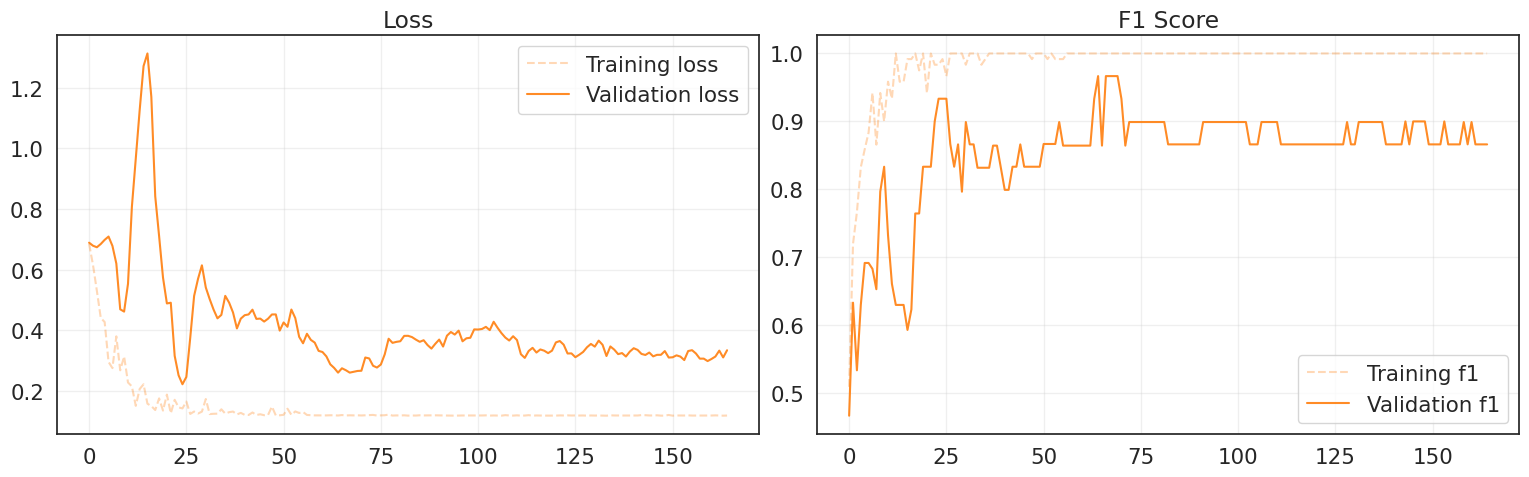

In [ ]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9667
Precision over the validation set: 0.9688
Recall over the validation set: 0.9667
F1 score over the validation set: 0.9666


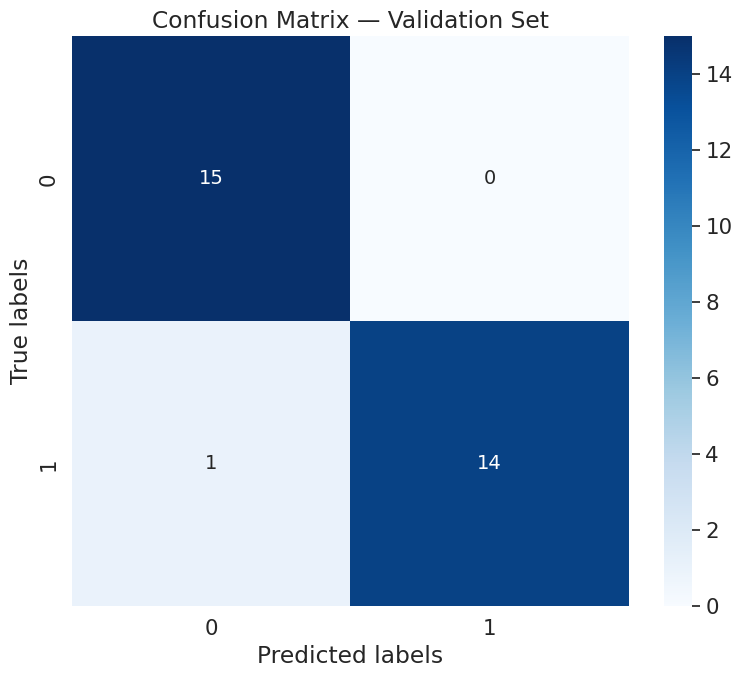

In [ ]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []

with torch.no_grad():  # Disable gradient computation
    for xb_dyn, xb_static, yb in val_loader:
        # Move data to device
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        # Forward pass: get model predictions
        logits = model(xb_dyn, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualize confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Binary classifier — hyperparameter tuning

Optuna over the model and window parameters, scored with StratifiedGroupKFold so
that folds are both subject-disjoint and class-balanced — necessary on 150
subjects, where an unstratified fold can end up badly skewed.


In [ ]:
def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 64, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.05)
    bidirectional = trial.suggest_categorical("bidirectional", [True, False])
    use_attention = trial.suggest_categorical("use_attention", [True, False])

    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-5, 1e-2)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-5, 1e-2)

    window_size = trial.suggest_int("window_size", 100, 400, step=50)
    stride = trial.suggest_int("stride", 25, 200, step=25)

    batch_size = 64

    sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    df_subjects = (X_train[['sample_index']]
        .drop_duplicates()
        .merge(y_train, on='sample_index')
    )

    f1_scores = []

    for train_idx, val_idx in sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']):
        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_tr = X_train[X_train['sample_index'].isin(train_users)]
        df_val = X_train[X_train['sample_index'].isin(val_users)]

        y_tr = y_train[y_train['sample_index'].isin(train_users)]
        y_val = y_train[y_train['sample_index'].isin(val_users)]

        X_tr_seq, X_tr_static, y_tr_seq = build_sequences(df_tr, y_tr, window=window_size, stride=stride, augment=True)
        X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_val, window=window_size, stride=stride, augment=False)

        train_ds = PirateDataset(X_tr_seq, X_tr_static, y_tr_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=batch_size)
        val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model = CNN_GRU_Binary(
            input_size_dynamic=X_tr_seq.shape[-1],
            input_size_static=X_tr_static.shape[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout_rate=dropout_rate,
            bidirectional=bidirectional,
            use_attention=use_attention
        ).to(device)

        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

        model, history = fit(
            model,
            train_loader,
            val_loader,
            epochs=500,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=100,
            evaluation_metric="val_f1",
            mode='max',
            restore_best_weights=True,
            writer=None,
            verbose=0
        )

        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn = xb_dyn.to(device).float()
                xb_static = xb_static.to(device).float()
                yb = yb.to(device)
                logits = model(xb_dyn, xb_static)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        f1_scores.append(f1_score(val_targets, val_preds, average='weighted'))

    return np.mean(f1_scores)

In [ ]:
study = optuna.create_study(
    direction="maximize",
    study_name="pirate_pain_optuna"
)

n_trials = 30
study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(f"F1 Score: {trial.value:.4f}")
print("Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

All Optuna studies are omitted for brevity, the best parameters found by these studies were used in the code below

In [ ]:
# best_params = study.best_trial.params

best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

# Assign parameters from dictionary
HIDDEN_SIZE = best_params["hidden_size"]
HIDDEN_LAYERS = best_params["num_layers"]
DROPOUT_RATE = best_params["dropout_rate"]
BIDIRECTIONAL = best_params["bidirectional"]
USE_ATTENTION = best_params["use_attention"]
LEARNING_RATE = best_params["learning_rate"]
L1_LAMBDA = best_params["l1_lambda"]
L2_LAMBDA = best_params["l2_lambda"]
WINDOW_SIZE = best_params["window_size"]
STRIDE = best_params["stride"]

# DataLoader settings
BATCH_SIZE = 64
N_SPLITS = 5
N_REPEATS = 3
SEED = 42

all_metrics = []
subjects = df_subjects['sample_index'].values
labels = df_subjects['label'].values

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
        print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
        df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
        y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
        y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

        # Build sequences using optimal window and stride
        X_train_seq, X_train_static, y_train_seq = build_sequences(
            df_train_fold, y_train_fold, window=WINDOW_SIZE, stride=STRIDE, augment=True
        )
        X_val_seq, X_val_static, y_val_seq = build_sequences(
            df_val_fold, y_val_fold, window=WINDOW_SIZE, stride=STRIDE, augment=False
        )

        train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        # Initialize model with best parameters
        model = CNN_GRU_Binary(
            input_size_dynamic=X_train_seq.shape[-1],
            input_size_static=X_train_static.shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=HIDDEN_LAYERS,
            dropout_rate=DROPOUT_RATE,
            bidirectional=BIDIRECTIONAL,
            use_attention=USE_ATTENTION
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=15
        )

        scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

        model, history = fit(
            model, train_loader, val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=L1_LAMBDA,
            l2_lambda=L2_LAMBDA,
            patience=PATIENCE,
            evaluation_metric='val_f1',
            mode='max',
            restore_best_weights=True,
            verbose=10,
            experiment_name=f"repeat{repeat+1}_fold{fold+1}",
            base_path=BASE_PATH,
            scheduler=scheduler
        )

        # Evaluate on validation fold
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
                logits = model(xb_dyn, xb_static)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        acc = accuracy_score(val_targets, val_preds)
        f1 = f1_score(val_targets, val_preds, average='weighted')
        prec = precision_score(val_targets, val_preds, average='weighted')
        rec = recall_score(val_targets, val_preds, average='weighted')

        all_metrics.append({
            'repeat': repeat+1, 'fold': fold+1,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
        })

# Summary statistics
metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
mean_metrics = metrics_array.mean(axis=0)
std_metrics = metrics_array.std(axis=0)

print("\nCross-validated results with Optuna best_params")
print(f"Accuracy: {mean_metrics[0]:.4f} \u00b1 {std_metrics[0]:.4f}")
print(f"F1 score: {mean_metrics[1]:.4f} \u00b1 {std_metrics[1]:.4f}")
print(f"Precision: {mean_metrics[2]:.4f} \u00b1 {std_metrics[2]:.4f}")
print(f"Recall: {mean_metrics[3]:.4f} \u00b1 {std_metrics[3]:.4f}")


--- Repeat 1, Fold 1 ---
Training 500 epochs...  (Validation: YES)
Epoch   1/500 | Train: Loss=1.3274, F1=0.5750 | Val: Loss=0.7020, F1=0.3333
Epoch  10/500 | Train: Loss=0.4499, F1=0.9700 | Val: Loss=1.2509, F1=0.5908
Epoch  20/500 | Train: Loss=0.3770, F1=0.9767 | Val: Loss=1.2213, F1=0.5238
Epoch  30/500 | Train: Loss=0.3440, F1=0.9683 | Val: Loss=0.3781, F1=0.8729
Epoch  40/500 | Train: Loss=0.2799, F1=0.9867 | Val: Loss=0.7193, F1=0.7674
Epoch  50/500 | Train: Loss=0.2348, F1=1.0000 | Val: Loss=0.5656, F1=0.8002
Epoch  60/500 | Train: Loss=0.2230, F1=0.9983 | Val: Loss=0.3853, F1=0.8867
Epoch  70/500 | Train: Loss=0.2141, F1=1.0000 | Val: Loss=0.7267, F1=0.7500
Epoch  80/500 | Train: Loss=0.2156, F1=0.9967 | Val: Loss=0.3555, F1=0.8933
Epoch  90/500 | Train: Loss=0.2068, F1=1.0000 | Val: Loss=0.4269, F1=0.8582
Epoch 100/500 | Train: Loss=0.2060, F1=1.0000 | Val: Loss=0.3310, F1=0.9129
Epoch 110/500 | Train: Loss=0.2044, F1=1.0000 | Val: Loss=0.5529, F1=0.8052
Epoch 120/500 | Trai

## Binary classifier — final model

Refit with the selected parameters on all 150 low/high subjects.


In [ ]:
EPOCHS = 500
PATIENCE = 100
BASE_PATH = ""

best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

# Extract parameters
HIDDEN_SIZE   = best_params["hidden_size"]
HIDDEN_LAYERS = best_params["num_layers"]
DROPOUT_RATE  = best_params["dropout_rate"]
BIDIRECTIONAL = best_params["bidirectional"]
USE_ATTENTION = best_params["use_attention"]
LEARNING_RATE = best_params["learning_rate"]
L1_LAMBDA     = best_params["l1_lambda"]
L2_LAMBDA     = best_params["l2_lambda"]
WINDOW_SIZE   = best_params["window_size"]
STRIDE        = best_params["stride"]


X_all_seq, X_all_static, y_all_seq = build_sequences(X_train, y_train,
    window=WINDOW_SIZE,
    stride=STRIDE,
    augment=False
)

full_ds = PirateDataset(X_all_seq, X_all_static, y_all_seq)
full_loader = make_loader(full_ds, batch_size=BATCH_SIZE, shuffle=True)


model = CNN_GRU_Binary(
    input_size_dynamic=X_all_seq.shape[-1],
    input_size_static=X_all_static.shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    use_attention=USE_ATTENTION
).to(device)

# Loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=L2_LAMBDA
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=15
)

# Mixed Precision
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# final training
model, history = fit(
    model,
    train_loader=full_loader,
    val_loader=None,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    patience=PATIENCE,
    evaluation_metric=None,
    mode="max",
    restore_best_weights=False,
    verbose=10,
    experiment_name="binary_classifier",
    base_path=BASE_PATH
)

Training 500 epochs...  (Validation: NO)
Epoch   1/500 | Train: Loss=1.3146, F1=0.5749
Epoch  10/500 | Train: Loss=0.4290, F1=0.9733
Epoch  20/500 | Train: Loss=0.3171, F1=0.9920
Epoch  30/500 | Train: Loss=0.2771, F1=0.9867
Epoch  40/500 | Train: Loss=0.2279, F1=1.0000
Epoch  50/500 | Train: Loss=0.2111, F1=0.9987
Epoch  60/500 | Train: Loss=0.1988, F1=1.0000
Epoch  70/500 | Train: Loss=0.1890, F1=1.0000
Epoch  80/500 | Train: Loss=0.1976, F1=0.9933
Epoch  90/500 | Train: Loss=0.1872, F1=0.9933
Epoch 100/500 | Train: Loss=0.1761, F1=0.9987
Epoch 110/500 | Train: Loss=0.1710, F1=1.0000
Epoch 120/500 | Train: Loss=0.2042, F1=0.9827
Epoch 130/500 | Train: Loss=0.1668, F1=1.0000
Epoch 140/500 | Train: Loss=0.1647, F1=1.0000
Epoch 150/500 | Train: Loss=0.1626, F1=1.0000
Epoch 160/500 | Train: Loss=0.1600, F1=1.0000
Epoch 170/500 | Train: Loss=0.1586, F1=1.0000
Epoch 180/500 | Train: Loss=0.1569, F1=1.0000
Epoch 190/500 | Train: Loss=0.1552, F1=1.0000
Epoch 200/500 | Train: Loss=0.1537, F1=

## Binary classifier — integration

Produces the binary logits for both the training subjects (out-of-fold, for
tuning the gate) and the test subjects, aligned to the ensemble's subject order.
The consistency checks in this section exist because an alignment error between
the binary head and the ensemble is silent — the shapes still match.


In [ ]:
best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

WINDOW = best_params["window_size"]
STRIDE = best_params["stride"]

# Data loading
train_df = pd.read_csv("Dataset/pirate_pain_train.csv")
train_labels = pd.read_csv("Dataset/pirate_pain_train_labels.csv")
test_df  = pd.read_csv("Dataset/pirate_pain_test.csv")

train_df.dropna(inplace=True)
train_labels.dropna(inplace=True)
test_df.dropna(inplace=True)

df_full = train_df.merge(train_labels, on="sample_index")
df_full = df_full[df_full["label"].isin(["low_pain", "high_pain"])]

X_train = df_full.drop(columns=["label"])
y_train = df_full[["sample_index", "label"]]

legs_map = {'two':2, 'one+peg_leg':1}
hands_map = {'two':2, 'one+hook_hand':1}
eyes_map = {'two':2, 'one+eye_patch':1}

for df in [X_train, test_df]:
    df["n_legs"]  = df["n_legs"].map(legs_map)
    df["n_hands"] = df["n_hands"].map(hands_map)
    df["n_eyes"]  = df["n_eyes"].map(eyes_map)

cols_to_drop = [c for c in X_train.columns if X_train[c].nunique()==1]
X_train.drop(columns=cols_to_drop, inplace=True)

y_train["label"] = y_train["label"].map({"low_pain":0, "high_pain":1})

joint_cols = [c for c in X_train.columns if "joint_" in c]
for df in [X_train, test_df]:
    for c in joint_cols:
        df[c] = df[c].astype(np.float32)



pain_cols = [f"pain_survey_{i+1}" for i in range(4)]
dyn_cols = pain_cols + joint_cols
static_cols = ["n_legs","n_hands","n_eyes"]

In [ ]:
means = X_train[dyn_cols].mean()
stds  = X_train[dyn_cols].std()

# z-score
X_train[dyn_cols] = (X_train[dyn_cols] - means) / (stds + 1e-8)
test_df[dyn_cols] = (test_df[dyn_cols] - means) / (stds + 1e-8)

In [ ]:
def build_sequences(df, y_df=None, window=WINDOW, stride=STRIDE, is_test=False):
    X_seq, X_static, seq_users, y_seq = [], [], [], []

    for sid in df["sample_index"].unique():
        temp = df[df["sample_index"]==sid]
        dyn = temp[dyn_cols].values.astype(np.float32)
        stat = temp[static_cols].iloc[0].values.astype(np.float32)

        pad_len = (window - len(dyn)%window) % window
        if pad_len>0:
            dyn = np.pad(dyn, ((0,pad_len),(0,0)), mode="edge")

        idx=0
        while idx + window <= len(dyn):
            win = dyn[idx:idx+window]

            X_seq.append(win)
            X_static.append(stat)
            seq_users.append(sid)
            if not is_test:
                y_seq.append(int(y_df[y_df["sample_index"]==sid]["label"].values[0]))
            idx += stride

    X_seq = np.array(X_seq, dtype=np.float32)
    X_static = np.array(X_static, dtype=np.float32)
    seq_users = np.array(seq_users, dtype=np.int32)

    if is_test:
        return X_seq, X_static, seq_users

    return X_seq, X_static, seq_users, np.array(y_seq, dtype=np.int64)


In [ ]:
# Build complete datasets (OOF and TEST)
Xtr_seq, Xtr_stat, users_tr_seq, ytr_seq = build_sequences(X_train, y_train)
Xte_seq, Xte_stat, users_te_seq = build_sequences(test_df, is_test=True)

print("Train seq:", Xtr_seq.shape)
print("Test  seq:", Xte_seq.shape)

Train seq: (750, 100, 34)
Test  seq: (6620, 100, 34)


In [ ]:
class PirateBinDS(Dataset):
    def __init__(self, Xs, Xst, ys=None, users=None):
        self.Xs= Xs
        self.Xst = Xst
        self.ys = ys
        self.users = users
    def __len__(self): return len(self.Xs)
    def __getitem__(self, i):
        if self.ys is None: return self.Xs[i], self.Xst[i], self.users[i]
        return self.Xs[i], self.Xst[i], self.ys[i], self.users[i]

train_ds = PirateBinDS(Xtr_seq, Xtr_stat, ytr_seq, users_tr_seq)
test_ds  = PirateBinDS(Xte_seq, Xte_stat, None,  users_te_seq)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

In [ ]:
# Model definition
class CNN_GRU_Binary(nn.Module):
    """Model B: CNN + GRU for low vs high pain classification.
    """

    def __init__(
        self,
        input_size_dynamic: int,
        input_size_static: int = 3,
        hidden_size: int = 160,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.use_attention = use_attention
        gru_input_size = 128

        #  CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size_dynamic, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # GRU Encoder
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )

        feat_dim = hidden_size * (2 if bidirectional else 1)

        #  Optional Attention
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(feat_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        #  Static Features MLP
        self.static_mlp = nn.Sequential(
            nn.Linear(input_size_static, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        static_dim = 16

        #  Final Classifier
        self.fc = nn.Sequential(
            nn.Linear(feat_dim + static_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 2)  # low vs high
        )

    def forward(self, x_dyn, x_static):
        """
        x_dyn: (batch, seq_len, dynamic_features)
        x_static: (batch, static_features)
        """
        # CNN expects (batch, feat, seq)
        x = x_dyn.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)

        # Attention or mean pooling
        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            seq_embed = torch.sum(out * attn_weights, dim=1)
        else:
            seq_embed = out.mean(dim=1)

        # Static embedding
        static_embed = self.static_mlp(x_static)

        # Combine
        combine = torch.cat([seq_embed, static_embed], dim=1)

        return self.fc(combine)


In [ ]:
# Loading the binary classifier weights
model_bin = CNN_GRU_Binary(
    input_size_dynamic=Xtr_seq.shape[-1],
    input_size_static=Xtr_stat.shape[-1],
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout_rate=best_params["dropout_rate"],
    bidirectional=best_params["bidirectional"],
    use_attention=best_params["use_attention"]
).to(device)

model_bin.load_state_dict(torch.load("models/binary_classifier_model.pt", map_location=device))
model_bin.eval()

CNN_GRU_Binary(
  (cnn): Sequential(
    (0): Conv1d(34, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
  )
  (gru): GRU(128, 224, num_layers=3, batch_first=True, dropout=0.5)
  (attention): Sequential(
    (0): Linear(in_features=224, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=False)
  )
  (static_mlp): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=240, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=2, bi

In [ ]:
# Inference (OOF + TEST)
def get_logits(loader, is_test=False):
    logits_all = []
    users_all  = []

    with torch.no_grad():
        for batch in tqdm(loader):
            if is_test:
                dyn, stat, u = batch
            else:
                dyn, stat, y, u = batch

            dyn, stat = dyn.to(device), stat.to(device)
            logits = model_bin(dyn, stat).cpu().numpy()

            logits_all.append(logits)
            users_all.append(u.numpy())

    return np.vstack(logits_all), np.concatenate(users_all)

train_logits_seq, train_users_seq = get_logits(train_loader, is_test=False)

test_logits_seq, test_users_seq = get_logits(test_loader, is_test=True)

100%|██████████| 26/26 [00:00<00:00, 41.72it/s]


In [ ]:
# Aggregation

def aggregate_user_logits(logits_seq, users_seq):
    uniq = np.unique(users_seq)
    user_logits = []

    for uid in uniq:
        idx = np.where(users_seq == uid)[0]
        avg = logits_seq[idx].mean(axis=0)
        user_logits.append(avg)

    return uniq, np.array(user_logits)


train_users_unique, train_logits_user = aggregate_user_logits(train_logits_seq, train_users_seq)
test_users_unique, test_logits_user = aggregate_user_logits(test_logits_seq, test_users_seq)

os.makedirs("logits/binary", exist_ok=True)

np.save("logits/binary/train_logits_bin_user.npy",  train_logits_user)
np.save("logits/binary/train_users_bin_user.npy",   train_users_unique)

np.save("logits/binary/test_logits_bin_user.npy", test_logits_user)

print("Files generated:")
print("   - train_logits_bin_user.npy")
print(train_logits_user.shape)
print("   - train_users_bin_user.npy")
print(train_users_unique.shape)
print("   - test_logits_bin_user.npy")
print(test_logits_user.shape)

  Files generated:
   - train_logits_bin_user.npy
(150, 2)
   - train_users_bin_user.npy
(150,)
   - test_logits_bin_user.npy
(1324, 2)


## Final ensemble with the confidence gate

The last stage. For each subject:

* if the ensemble predicts `no_pain`, keep it — the gate never fires there;
* otherwise renormalise the ensemble's probabilities over `{low, high}` only,
  asking "given that this subject is in pain, how sure are we which kind";
* if that confidence is below `t_conf`, fuse the ensemble and binary
  probabilities with weight `alpha`; otherwise keep the ensemble's answer.

The shipped parameters are `alpha = 0.524` and `t_conf = 0.59`. Worth being
explicit about what that threshold does in practice: it is high enough that the
ensemble is almost never judged uncertain, so the gate fires on **1 test subject
out of 1324**. The mechanism is implemented and correct, but at this operating
point it is effectively dormant — the gain over the A+B ensemble comes from
model C. `src/gate.py` ships a `tune_gate()` grid search and returns
intervention counts so this is visible rather than assumed.

The output of this cell is `submissions/submission_final.csv`, reproducible from
the committed logits with `python scripts/rebuild_submission.py`.


In [ ]:
# A, B, C logits
aligned_logits_A = np.load("test_logits_A_9589_final.npy")
aligned_logits_B = np.load("test_logits_B_9589_final.npy")
aligned_logits_C = np.load("test_logits_C_9589_final.npy")

print("A test logits:", aligned_logits_A.shape)
print("B test logits:", aligned_logits_B.shape)
print("C test logits:", aligned_logits_C.shape)

A test logits: (1324, 3)
B test logits: (1324, 3)
C test logits: (1324, 3)


In [ ]:
# Loading OOF labels and user ordering

# 661 users
y_oof = np.load("oof_logits/oof_labels.npy")
oof_users = np.load("oof_logits/oof_user_ids.npy")

print("OOF y:", y_oof.shape)
print("OOF users:", oof_users.shape)

OOF y: (661,)
OOF users: (661,)


In [ ]:
# Loading the binary logits used by the gating module

train_logits_bin = np.load("logits/binary/train_logits_bin_user.npy")
train_users_bin = np.load("logits/binary/train_users_bin_user.npy")

test_logits_bin = np.load("logits/binary/test_logits_bin_user.npy")

print("Bin train logits:", train_logits_bin.shape)
print("Bin train users:", train_users_bin.shape)
print("Bin test logits:", test_logits_bin.shape)

Bin train logits: (150, 2)
Bin train users: (150,)
Bin test logits: (1324, 2)


In [ ]:
# Checking shape consistency and alignment

errors = []

if not (aligned_logits_A.shape[0] == aligned_logits_B.shape[0] == aligned_logits_C.shape[0] == test_logits_bin.shape[0] == 1324):
    errors.append("Number of test users does NOT match across A/B/C/BIN")
else:
    print("TEST: All models have 1324 predictions (OK)")


if y_oof.shape[0] != oof_users.shape[0]:
    errors.append("y_oof and oof_users have different lengths")
else:
    print("OOF: y_oof and oof_users have consistent shapes")


if aligned_logits_A.shape[1] != 3: errors.append("A logits are not in shape (N,3)")
if aligned_logits_B.shape[1] != 3: errors.append("B logits are not in shape (N,3)")
if aligned_logits_C.shape[1] != 3: errors.append("C logits are not in shape (N,3)")
else:
    print("Logits A/B/C have correct shape (N,3)")

if test_logits_bin.shape[1] != 2:
    errors.append("Binary test logits are not (N,2)")
else:
    print("Binary logits have correct shape (N,2)")

sample_sub = pd.read_csv("Dataset/sample_submission.csv")
test_users_sub = sample_sub["sample_index"].values

if len(test_users_sub) != aligned_logits_A.shape[0]:
    errors.append("Number of users in sample_submission does not match test logits")
else:
    print("sample_submission contains 1324 users")


# Duplicated users
if len(np.unique(test_users_sub)) != 1324:
    errors.append("sample_submission contains duplicated users")
else:
    print("No duplicates found in sample_submission")

if len(errors) == 0:
    print("All files are consistent and ready for gating.")
else:
    print("Issues found")
    for e in errors:
        print(" -", e)

print("\nDONE.")

TEST: All models have 1324 predictions (OK)
OOF: y_oof and oof_users have consistent shapes
Logits A/B/C have correct shape (N,3)
 Binary logits have correct shape (N,2)
sample_submission contains 1324 users
No duplicates found in sample_submission
All files are consistent and ready for gating.

DONE.


In [ ]:
# Load oof logits A/B/C
oof_A = np.load("oof_logits/oof_logits_A.npy")
oof_B = np.load("oof_logits/oof_logits_B.npy")
oof_C = np.load("oof_logits_C.npy")

print("OOF A:", oof_A.shape)
print("OOF B:", oof_B.shape)
print("OOF C:", oof_C.shape)


# Load oof labels
y_oof = np.load("oof_logits/oof_labels.npy")
oof_users = np.load("oof_logits/oof_user_ids.npy")

print("OOF labels:", y_oof.shape)
print("OOF users:", oof_users.shape)


bin_train_logits = np.load("logits/binary/train_logits_bin_user.npy")
bin_train_users  = np.load("logits/binary/train_users_bin_user.npy")

bin_test_logits  = np.load("logits/binary/test_logits_bin_user.npy")

print("BIN train logits:", bin_train_logits.shape)
print("BIN train users :", bin_train_users.shape)
print("BIN test logits :", bin_test_logits.shape)


# Load test logits A/B/C
test_A = np.load("test_logits_A_9589_final.npy")
test_B = np.load("test_logits_B_9589_final.npy")
test_C = np.load("test_logits_C_9589_final.npy")

print("TEST A:", test_A.shape)
print("TEST B:", test_B.shape)
print("TEST C:", test_C.shape)

OOF A: (661, 3)
OOF B: (661, 3)
OOF C: (1983, 3)
OOF labels: (661,)
OOF users: (661,)
BIN train logits: (150, 2)
BIN train users : (150,)
BIN test logits : (1324, 2)
TEST A: (1324, 3)
TEST B: (1324, 3)
TEST C: (1324, 3)


In [ ]:
# Fix to align C’s OOF at the user level

NUM_CLASSES = 3

print("Loading base OOF (A/B) preserving user order")
oof_users = np.load("oof_logits/oof_user_ids.npy")
print("User ids OOF:", oof_users.shape)

print("\n Loading OOF C (window-level)")
oof_C_seq   = np.load("oof_logits_C.npy")
oof_users_seq = np.load("oof_users_C.npy")
print("C window shapes:", oof_C_seq.shape, oof_users_seq.shape)


# User-level aggregation of window logits (average)
def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    df = pd.DataFrame(seq_logits, columns=[f"logit_{k}" for k in range(num_classes)])
    df["user_id"] = seq_user_ids

    df_user = (
        df.groupby("user_id")[ [f"logit_{k}" for k in range(num_classes)] ]
          .mean()
          .reset_index()
          .sort_values("user_id")
    )

    user_ids = df_user["user_id"].values
    user_logits = df_user[[f"logit_{k}" for k in range(num_classes)]].values
    return user_ids, user_logits


# User-level aggregation
user_ids_C, oof_C_user = aggregate_user_logits(
    oof_C_seq,
    oof_users_seq,
    num_classes=NUM_CLASSES
)

print("\nOOF C user-level:", oof_C_user.shape)
print("User ids (C):", len(user_ids_C))


# Align C OOF to user order
print("\nAlign C OOF to user order")

mapC = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_C = np.vstack([
    oof_C_user[mapC[uid]] for uid in oof_users
])

# Saving file
np.save("oof_logits_C_user_aligned.npy", aligned_C)

Loading base OOF (A/B) preserving user order
User ids OOF: (661,)

 Loading OOF C (window-level)
C window shapes: (1983, 3) (1983,)

OOF C user-level: (661, 3)
User ids (C): 661

Align C OOF to user order


In [ ]:
# Support function

def softmax_np(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

oof_C = np.load("oof_logits_C_user_aligned.npy")

wA=0.4412
wB=0.3246
wC=0.2342

logits_ens_oof = (
    wA * oof_A +
    wB * oof_B +
    wC * oof_C
)


# Align binary users to ensemble users

bin_map = {uid: i for i, uid in enumerate(bin_train_users)}

# Boolean array: True if user is low/high to present in binary
is_lh = np.array([uid in bin_map for uid in oof_users])

# Binary logits aligned to OOF ensemble order
bin_logits_aligned = np.zeros((661, 2))
bin_available = np.zeros(661, dtype=bool)

for i, uid in enumerate(oof_users):
    if uid in bin_map:
        bin_logits_aligned[i] = bin_train_logits[bin_map[uid]]
        bin_available[i] = True
    else:
        # placeholder (will never be used on no-pain)
        bin_logits_aligned[i] = [0.5, 0.5]

print("Users with binary available:", bin_available.sum())

Users with binary available: 150


In [ ]:
def apply_gate(logits_ens, logits_bin, bin_mask, y_true, alpha, t_conf):
    """
    logits_ens : (N, 3)  logits dell'ensemble A+B+C
    logits_bin : (N, 2)  aligned binary logits (low, high)
    bin_mask   : (N,)    True where a binary (low/high) prediction exists for that user
    y_true     : (N,)    labels vere (0=no, 1=low, 2=high)
    alpha      : float   weight of the binary head in the fusion
    t_conf     : float   max(low/high) confidence at or above which the gate does NOT fire
    """N = len(logits_ens)
    preds_final = np.zeros(N, dtype=int)
    debug_logs = []

    total_interventions = 0
    fixes = 0
    worsened = 0
    both_correct = 0
    both_wrong = 0

    ens_correct_total = 0
    gate_correct_total = 0

    for i in range(N):
        p_ens = softmax_np(logits_ens[i])
        ens_pred = int(np.argmax(p_ens))
        true = int(y_true[i])

        # accuracy ensemble
        if ens_pred == true:
            ens_correct_total += 1

        # Scenario 1: Ensemble predicts NO PAIN → gate is never triggered
        if ens_pred == 0:
            final_pred = 0
            preds_final[i] = final_pred
            if final_pred == true:
                gate_correct_total += 1
            continue

        # Scenario 2: Ensemble output is LOW or HIGH
        # Probability computed only for LOW and HIGH
        p_lh_ens = np.array([p_ens[1], p_ens[2]])
        p_lh_ens = p_lh_ens / p_lh_ens.sum()
        max_lh_conf = float(p_lh_ens.max())

        # No binary prediction, or the ensemble is confident -> trust the ensemble
        if (not bin_mask[i]) or (max_lh_conf >= t_conf):
            final_pred = ens_pred
            preds_final[i] = final_pred
            if final_pred == true:
                gate_correct_total += 1
            continue

        # Scenario 3: Ensemble uncertain about LOW/HIGH → gating mechanism activates
        total_interventions += 1

        # Binary prob (low, high)
        p_bin = softmax_np(logits_bin[i])

        # Weighted combination of LOW and HIGH probabilities
        p_fused = alpha * p_bin + (1.0 - alpha) * p_lh_ens

        # p_fused[0] → low (1), p_fused[1] → high (2)
        pred_lh = 0 if p_fused[0] >= p_fused[1] else 1
        final_pred = 1 + pred_lh
        preds_final[i] = final_pred

        # Final accuracy
        if final_pred == true:
            gate_correct_total += 1

        # Ensemble vs Gate: Comparison Statistics
        ens_correct = (ens_pred == true)
        gate_correct = (final_pred == true)

        if (not ens_correct) and gate_correct:
            fixes += 1
        elif ens_correct and (not gate_correct):
            worsened += 1
        elif ens_correct and gate_correct:
            both_correct += 1
        else:
            both_wrong += 1


        debug_logs.append({
            "user_idx": i,
            "true_label": true,
            "ensemble_probs": p_ens,
            "ensemble_lh": p_lh_ens,
            "max_lh_conf": max_lh_conf,
            "bin_probs": p_bin,
            "p_fused": p_fused,
            "ensemble_pred": ens_pred,
            "final_pred": final_pred,
        })

    stats = {
        "interventions": total_interventions,
        "fixes": fixes,
        "worsened": worsened,
        "both_correct": both_correct,
        "both_wrong": both_wrong,
        "ensemble_accuracy": ens_correct_total / N,
        "gate_accuracy": gate_correct_total / N,
    }

    return np.array(preds_final), debug_logs, stats

In [ ]:
print("Test shapes:", test_A.shape, test_B.shape, test_C.shape)

# Ensemble A-B-C
logits_ens_test = (
    wA * test_A +
    wB * test_B +
    wC * test_C
)

if bin_test_logits.shape[0] != logits_ens_test.shape[0]:
    raise ValueError("Binary test logits are NOT aligned with ensemble logits!")

bin_available_test = np.ones(len(bin_test_logits), dtype=bool)

# dummy ground truth for compatibility with apply_gate
y_dummy = np.zeros(len(logits_ens_test), dtype=int)

# Apply the gate to TEST
final_preds_test, debug_test, stats_test = apply_gate(
    logits_ens_test,
    bin_test_logits,
    bin_available_test,
    y_dummy,            # NOT used, only required for the function signature
    0.524,              # alpha found during previous tuning
    0.59
)

print("\nFinal prediction distribution:", np.bincount(final_preds_test))

sample = pd.read_csv("Dataset/sample_submission.csv")
submission = sample.copy()

# final_preds_test contains 0/1/2, map them to strings
label_map = {
    0: "no_pain",
    1: "low_pain",
    2: "high_pain"
}

submission["label"] = [label_map[int(x)] for x in final_preds_test]

print(submission["label"].value_counts())

submission.to_csv("submission_final.csv", index=False)

print("\nSUBMISSION SUCCESSFULLY CREATED: submission_final.csv")

Test shapes: (1324, 3) (1324, 3) (1324, 3)

Final prediction distribution: [1028  176  120]
label
no_pain      1028
low_pain      176
high_pain     120
Name: count, dtype: int64

SUBMISSION SUCCESSFULLY CREATED: submission_final.csv
